# **Analisis clustering con K-means**


/tmp/ipykernel_1759686/4228854378.py:25: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  conn  = Queen.from_dataframe(gdf).sparse


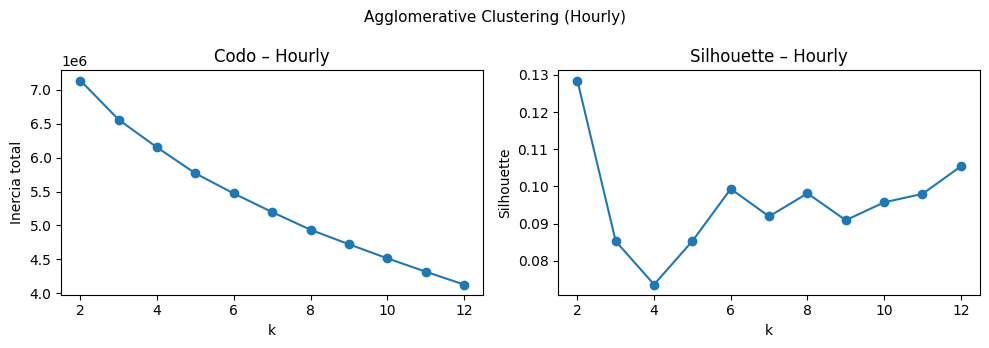

/tmp/ipykernel_1759686/4228854378.py:25: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  conn  = Queen.from_dataframe(gdf).sparse


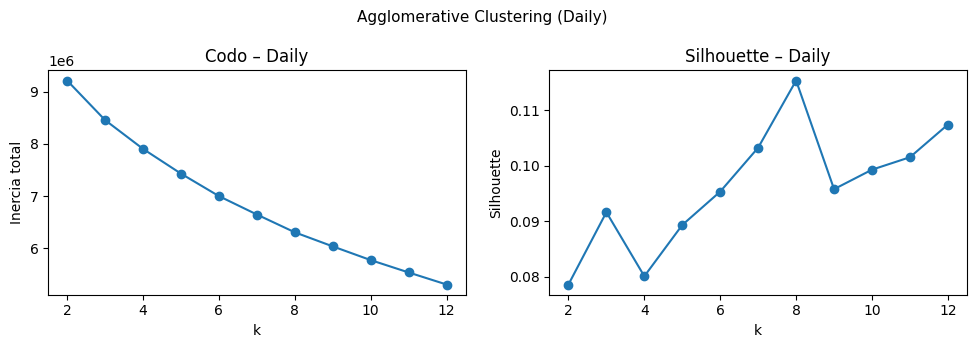

/tmp/ipykernel_1759686/4228854378.py:25: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  conn  = Queen.from_dataframe(gdf).sparse


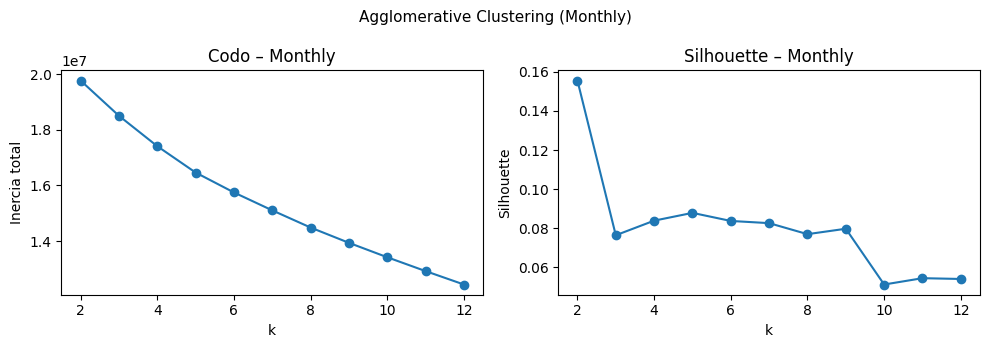

In [2]:
import pandas as pd, numpy as np
import geopandas as gpd
from libpysal.weights import Queen
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# ─── rutas y archivos ────────────────────────────────────────────
dir_data  = '../../DATA/'
ruta_coor = f'{dir_data}shape_files/'
csvs = {
    'hourly'  : f'{dir_data}all_stations_SIATA_hourly.csv',
    'daily'   : f'{dir_data}all_stations_SIATA_daily.csv',
    'monthly' : f'{dir_data}all_stations_SIATA_monthly.csv'
}

pluvios = gpd.read_file(ruta_coor + "Est_All.shp").set_index('codigo')
Ks      = range(2, 13)                        # valores de k a evaluar

# ─── función auxiliar: codo + silhouette ─────────────────────────
def elbow_silhouette(feats, pluvios_gdf, nombre):
    feats.index = feats.index.astype(pluvios_gdf.index.dtype)
    gdf   = pluvios_gdf.join(feats, how='inner')
    X     = feats.loc[gdf.index].values
    conn  = Queen.from_dataframe(gdf).sparse

    inertias, sil_scores = [], []
    for k in Ks:
        labels = AgglomerativeClustering(
                    n_clusters=k, linkage='ward',
                    connectivity=conn).fit_predict(X)

        # inercia (suma de cuadrados intra-cluster)
        inertia = 0.0
        for cid in np.unique(labels):
            pts      = X[labels == cid]
            centroid = pts.mean(axis=0)
            inertia += ((pts - centroid) ** 2).sum()
        inertias.append(inertia)

        # silhouette promedio
        sil_scores.append(silhouette_score(X, labels))

    # ── gráficos ────────────────────────────────────────────────
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
    ax[0].plot(Ks, inertias, marker='o')
    ax[0].set_xlabel('k'); ax[0].set_ylabel('Inercia total')
    ax[0].set_title(f'Codo – {nombre}')

    ax[1].plot(Ks, sil_scores, marker='o')
    ax[1].set_xlabel('k'); ax[1].set_ylabel('Silhouette')
    ax[1].set_title(f'Silhouette – {nombre}')

    fig.suptitle(f'Agglomerative Clustering ({nombre})', fontsize=11)
    plt.tight_layout(); plt.show()

# ─── loop para hourly, daily y monthly ───────────────────────────
for escala, path in csvs.items():
    feats = pd.read_csv(path, index_col=0).T.fillna(0)
    elbow_silhouette(feats, pluvios, escala.capitalize())


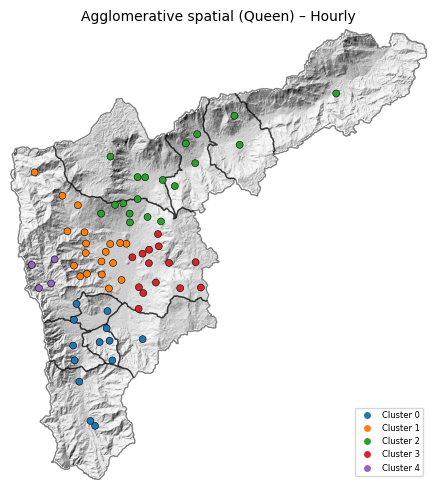

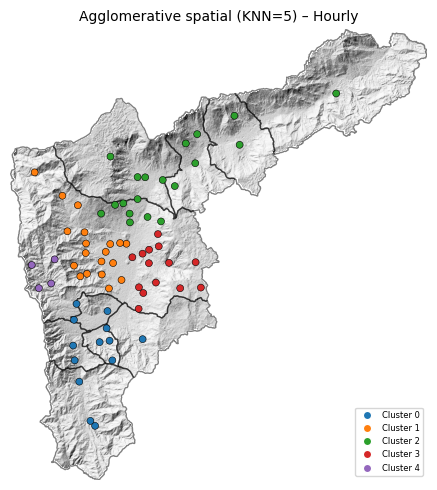

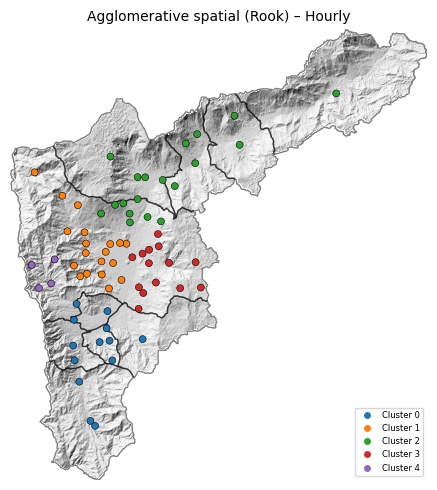

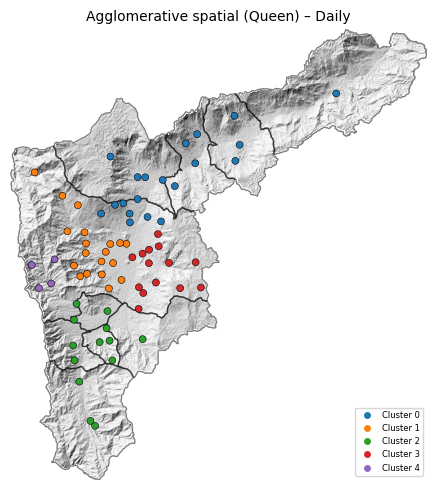

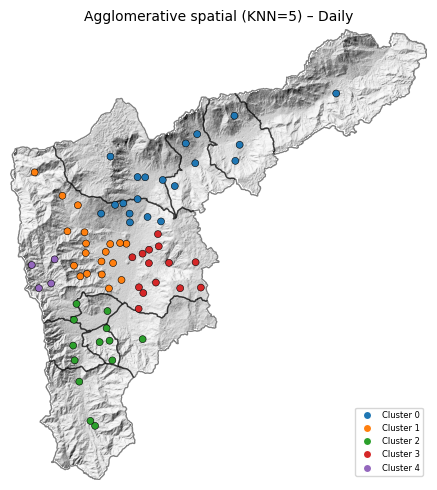

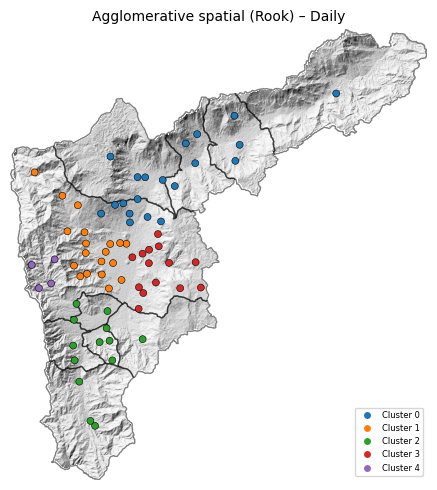

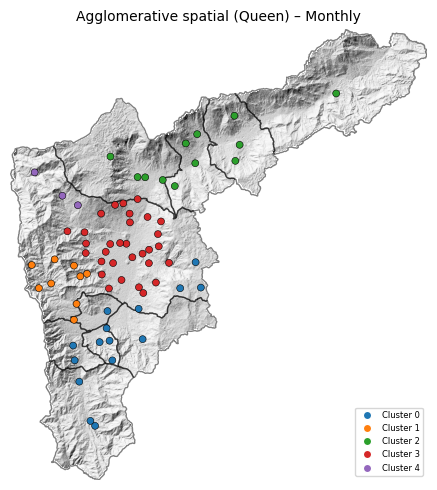

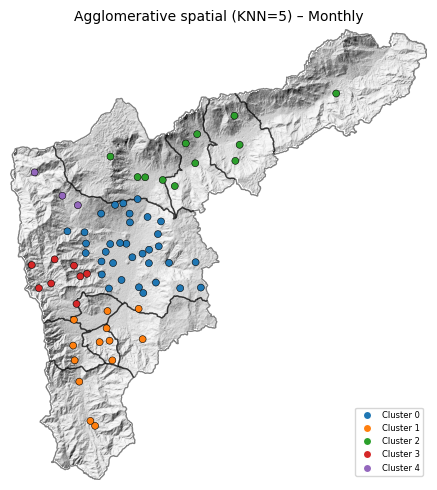

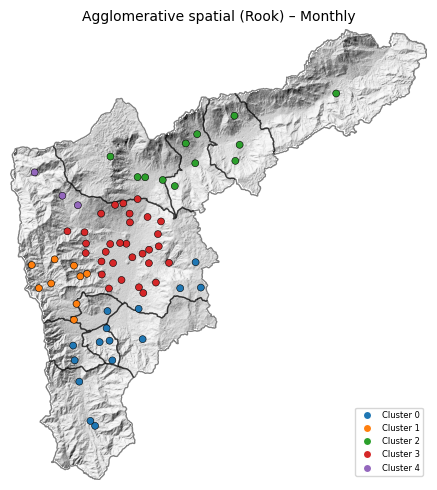

In [3]:
import pandas as pd, numpy as np
import geopandas as gpd
from sklearn.preprocessing   import StandardScaler
from sklearn.cluster         import AgglomerativeClustering
from libpysal.weights        import Queen, KNN, Rook         # parte de PySAL
from scipy import sparse
import geopandas as gpd, rasterio as rio
from rasterio.plot import show
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# --- datos ---------------------------------------------------
dir_data  = '../../DATA/'
ruta_coor = f'{dir_data}shape_files/'
csvs = {
    'hourly'  : f'{dir_data}all_stations_SIATA_hourly.csv',
    'daily'   : f'{dir_data}all_stations_SIATA_daily.csv',
    'monthly' : f'{dir_data}all_stations_SIATA_monthly.csv'
}

pluvios   = gpd.read_file(ruta_coor + "Est_All.shp").set_index('codigo')

main      = f'{dir_data}shape_files/'
ruta_amva = '/home/oisanchezp/Geociencias/shape_files/'
ruta_coor = f'{dir_data}shape_files/'

hill_src  = rio.open(main + "DEM_west_Hillshade_Clip_r.tif")
hill      = hill_src.read(1)
hill      = np.where(hill == hill[0, 0], np.nan, hill)          # quitar nodata

AMVA      = gpd.read_file(f"{ruta_amva}mpios_amva_qnk.shp")
pluvios   = gpd.read_file(ruta_coor + "Est_All.shp").set_index('codigo')


def plot_clusters(gdf, title):
    fig, ax = plt.subplots(figsize=(5,5))
    show(hill, transform=hill_src.transform, ax=ax, cmap='Greys_r')
    AMVA.plot(ax=ax, facecolor='none', edgecolor='black', alpha=0.5)

    gdf.plot(ax=ax, c=gdf['color'], edgecolor='k', markersize=25, linewidth=0.4)

    handles = [Line2D([0],[0], marker='o', color='w',
                      markerfacecolor=f'C{i}', markersize=6,
                      label=f'Cluster {i}') for i in sorted(gdf.cluster.unique())]
    ax.legend(handles=handles, loc='lower right', fontsize=6)
    ax.set_title(title,fontdict={'fontsize': 10}); ax.set_axis_off(); plt.tight_layout(); plt.show()

for escala, file in csvs.items():
    feats  = pd.read_csv(file, index_col=0).T.fillna(0)
    feats.index = feats.index.astype(pluvios.index.dtype)  # asegurar tipos compatibles
    gdf = pluvios.join(feats, how='inner')  # unir datos de estaciones

    # --- 1. matriz de contigüidad Queen --------------------------
    w_q   = Queen.from_dataframe(gdf, use_index=True)   # cada estación vecina si comparten arista o vértice
    conn  = w_q.sparse                      # matriz dispersa SciPy (filas ordenadas ≡ índice)

    # --- 2. clustering jerárquico espacial -----------------------
    X     = feats.values  # mismos índices
    model = AgglomerativeClustering( n_clusters = 5,
                                    linkage    = 'ward',        # minimiza varianza intra-cluster
                                    connectivity = conn )
    labels = model.fit_predict(X)

    feats.index = gdf.index.astype(feats.index.dtype)
    # --- 3. guardar y mapear -------------------------------------
    gdf.loc[feats.index, 'cluster'] = labels
    gdf['cluster'] = gdf['cluster'].astype(int)   
    gdf['color'] = gdf['cluster'].map(lambda c: f'C{c}')

    plot_clusters(gdf.dropna(subset=['cluster']),
                f'Agglomerative spatial (Queen) – {escala.capitalize()}')

# --- 4. matriz de contigüidad KNN -----------------------------
    w_knn = KNN.from_dataframe(gdf, k=5, use_index=True
    )  # cada estación vecina si está entre las 5 más cercanas
    conn  = w_knn.sparse  # matriz dispersa SciPy (filas ordenadas ≡ índice)        
    X     = feats.values  # mismos índices
    model = AgglomerativeClustering( n_clusters = 5,
                                    linkage    = 'ward',        # minimiza varianza intra-cluster
                                    connectivity = conn )
    labels = model.fit_predict(X)
    feats.index = gdf.index.astype(feats.index.dtype)
    # --- 5. guardar y mapear -------------------------------------
    gdf.loc[feats.index, 'cluster'] = labels
    gdf['cluster'] = gdf['cluster'].astype(int)
    gdf['color'] = gdf['cluster'].map(lambda c: f'C{c}')
    plot_clusters(gdf.dropna(subset=['cluster']),
                f'Agglomerative spatial (KNN=5) – {escala.capitalize()}')
    
    # --- 6. matriz de contigüidad Rook ---------------------------
    w_rook = Rook.from_dataframe(gdf, use_index=True)  # cada estación vecina si comparten arista
    conn   = w_rook.sparse  # matriz dispersa SciPy (filas ordenadas ≡ índice)
    X      = feats.values
    model  = AgglomerativeClustering( n_clusters = 5,
                                      linkage    = 'ward',        # minimiza varianza intra-cluster
                                      connectivity = conn )
    labels  = model.fit_predict(X)
    feats.index = gdf.index.astype(feats.index.dtype)
    # --- 7. guardar y mapear -------------------------------------
    gdf.loc[feats.index, 'cluster'] = labels
    gdf['cluster'] = gdf['cluster'].astype(int)
    gdf['color'] = gdf['cluster'].map(lambda c: f'C{c}')
    plot_clusters(gdf.dropna(subset=['cluster']),
                f'Agglomerative spatial (Rook) – {escala.capitalize()}')


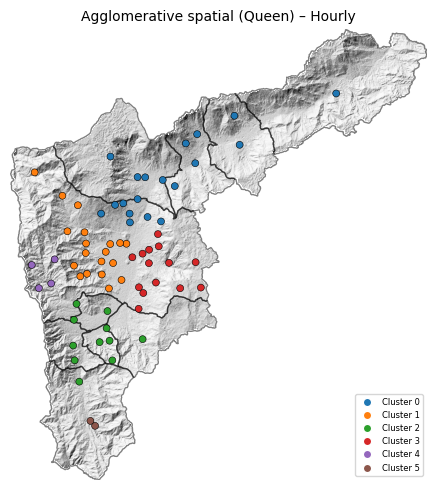

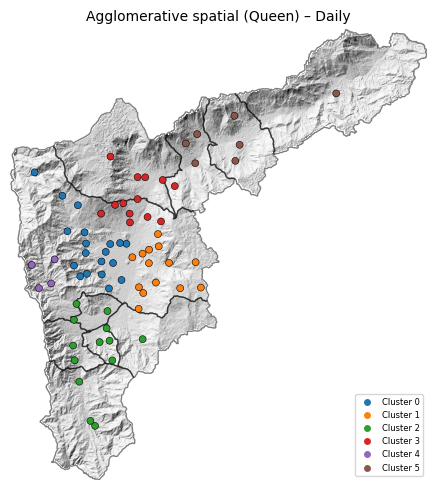

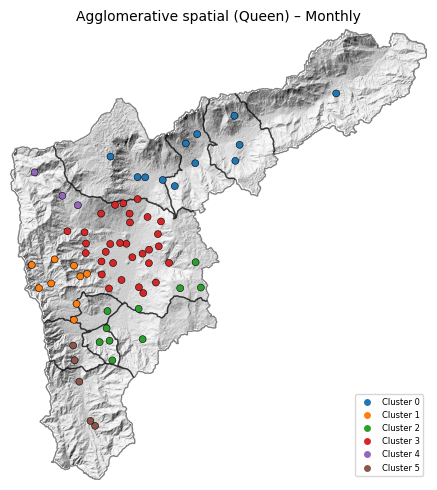

In [ ]:
import pandas as pd, numpy as np
import geopandas as gpd
from sklearn.preprocessing   import StandardScaler
from sklearn.cluster         import AgglomerativeClustering
from libpysal.weights        import Queen, KNN, Rook         # parte de PySAL
from scipy import sparse
import geopandas as gpd, rasterio as rio
from rasterio.plot import show
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# --- datos ---------------------------------------------------
dir_data  = '../../DATA/'
ruta_coor = f'{dir_data}shape_files/'
csvs = {
    'hourly'  : f'{dir_data}all_stations_SIATA_hourly.csv',
    'daily'   : f'{dir_data}all_stations_SIATA_daily.csv',
    'monthly' : f'{dir_data}all_stations_SIATA_monthly.csv'
}

pluvios   = gpd.read_file(ruta_coor + "Est_All.shp").set_index('codigo')

main      = f'{dir_data}shape_files/'
ruta_amva = '/home/oisanchezp/Geociencias/shape_files/'
ruta_coor = f'{dir_data}shape_files/'

hill_src  = rio.open(main + "DEM_west_Hillshade_Clip_r.tif")
hill      = hill_src.read(1)
hill      = np.where(hill == hill[0, 0], np.nan, hill)          # quitar nodata

AMVA      = gpd.read_file(f"{ruta_amva}mpios_amva_qnk.shp")
pluvios   = gpd.read_file(ruta_coor + "Est_All.shp").set_index('codigo')


def plot_clusters(gdf, title):
    fig, ax = plt.subplots(figsize=(5,5))
    show(hill, transform=hill_src.transform, ax=ax, cmap='Greys_r')
    AMVA.plot(ax=ax, facecolor='none', edgecolor='black', alpha=0.5)

    gdf.plot(ax=ax, c=gdf['color'], edgecolor='k', markersize=25, linewidth=0.4)

    handles = [Line2D([0],[0], marker='o', color='w',
                      markerfacecolor=f'C{i}', markersize=6,
                      label=f'Cluster {i}') for i in sorted(gdf.cluster.unique())]
    ax.legend(handles=handles, loc='lower right', fontsize=6)
    ax.set_title(title,fontdict={'fontsize': 10}); ax.set_axis_off(); plt.tight_layout(); plt.show()

for escala, file in csvs.items():
    feats  = pd.read_csv(file, index_col=0).T.fillna(0)
    feats.index = feats.index.astype(pluvios.index.dtype)  # asegurar tipos compatibles
    gdf = pluvios.join(feats, how='inner')  # unir datos de estaciones

    # --- 1. matriz de contigüidad Queen --------------------------
    w_q   = Queen.from_dataframe(gdf, use_index=True)   # cada estación vecina si comparten arista o vértice
    conn  = w_q.sparse                      # matriz dispersa SciPy (filas ordenadas ≡ índice)

    # --- 2. clustering jerárquico espacial -----------------------
    X     = feats.values  # mismos índices
    model = AgglomerativeClustering( n_clusters = 6,
                                    linkage    = 'ward',        # minimiza varianza intra-cluster
                                    connectivity = conn )
    labels = model.fit_predict(X)

    feats.index = gdf.index.astype(feats.index.dtype)
    # --- 3. guardar y mapear -------------------------------------
    gdf.loc[feats.index, 'cluster'] = labels
    gdf['cluster'] = gdf['cluster'].astype(int)   
    gdf['color'] = gdf['cluster'].map(lambda c: f'C{c}')

    plot_clusters(gdf.dropna(subset=['cluster']),
                f'Agglomerative spatial (Queen) – {escala.capitalize()}')


/tmp/ipykernel_369055/2165940128.py:9: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  conn = Queen.from_dataframe(gdf).sparse


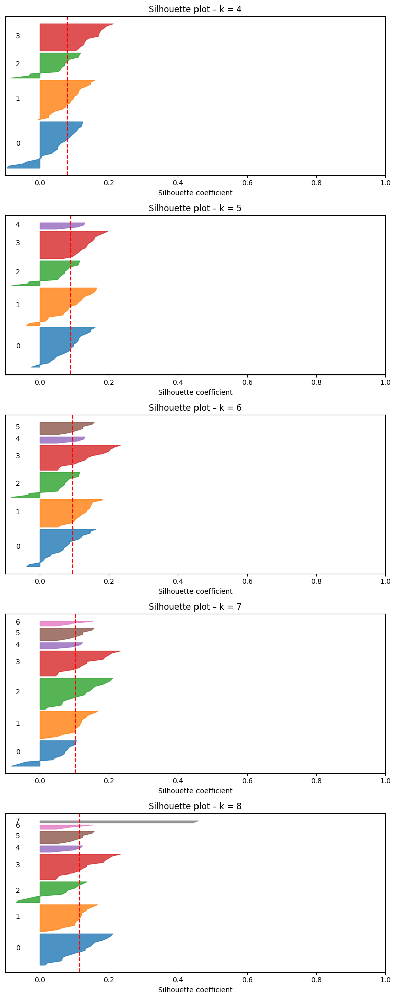

In [8]:
import numpy as np, matplotlib.pyplot as plt, matplotlib.cm as cm
from sklearn.cluster   import AgglomerativeClustering
from sklearn.metrics   import silhouette_samples, silhouette_score
from sklearn.decomposition import PCA

# --- configuración ----------------------------------------------------------
Ks = [ 4, 5, 6, 7, 8]                       # elige los k que quieras comparar
X  = feats.values                    # matriz de características (misma que usaste)
conn = Queen.from_dataframe(gdf).sparse

# --- clustering y métricas --------------------------------------------------
nrows = len(Ks)
fig, axes = plt.subplots(nrows, 1, figsize=(8, 4 * nrows),
                         sharex=False, sharey=False)

if nrows == 1:
    axes = [axes]  # por si solo hay un k, convertir en lista

colors = [f'C{i}' for i in range(max(Ks))]

for row, k in enumerate(Ks):
    ax = axes[row]
    
    labels   = AgglomerativeClustering(n_clusters=k,
                                       linkage='ward',
                                       connectivity=conn).fit_predict(X)
    sil_vals = silhouette_samples(X, labels)
    sil_avg  = sil_vals.mean()

    y_lower = 0
    for cid in range(k):
        vals = sil_vals[labels == cid]
        vals.sort()
        y_upper = y_lower + len(vals)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                         color=colors[cid], alpha=0.8)
        ax.text(-0.07, (y_lower + y_upper)/2, str(cid), va='center')
        y_lower = y_upper

    ax.axvline(sil_avg, color='red', linestyle='--')
    ax.set_xlim(-0.1, 1.0)
    ax.set_yticks([])
    ax.set_xlabel('Silhouette coefficient')
    ax.set_title(f'Silhouette plot – k = {k}')

plt.tight_layout()
plt.show()

### **ANALISIS DE PCA**


(69,)
37 componentes principales para 80 % varianza
(69, 101545)
[[-0.00531769 -0.00041532 -0.00082714 ... -0.00131813 -0.00131813
  -0.00131813]]


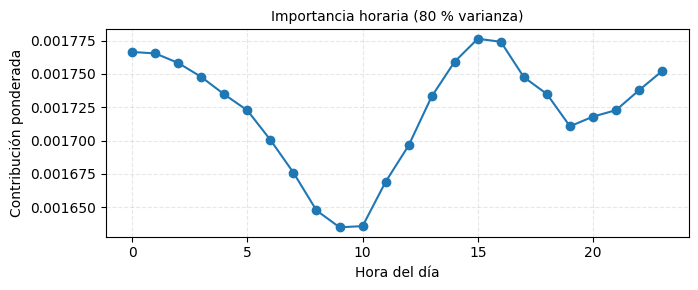

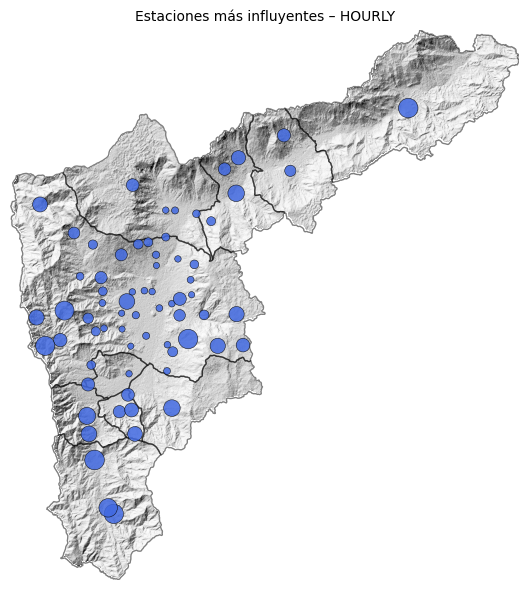

In [ ]:
import pandas as pd, numpy as np
import geopandas as gpd
from sklearn.preprocessing   import StandardScaler
from sklearn.cluster         import AgglomerativeClustering
from libpysal.weights        import Queen, KNN, Rook         # parte de PySAL
from scipy import sparse
import geopandas as gpd, rasterio as rio
from rasterio.plot import show
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
#define PCA
from sklearn.decomposition import PCA


# --- datos ---------------------------------------------------
dir_data  = '../../DATA/'
ruta_coor = f'{dir_data}shape_files/'
csvs = {
    'hourly'  : f'{dir_data}all_stations_SIATA_hourly.csv',
    'daily'   : f'{dir_data}all_stations_SIATA_daily.csv',
    'monthly' : f'{dir_data}all_stations_SIATA_monthly.csv'
}


# ─────────────────────────  CONFIGURACIÓN  ──────────────────────────
dir_data  = '../../DATA/'
ruta_coor = f'{dir_data}shape_files/'
csvs = {
    'hourly'  : f'{dir_data}all_stations_SIATA_hourly.csv',
    #'daily'   : f'{dir_data}all_stations_SIATA_daily.csv',
    #'monthly' : f'{dir_data}all_stations_SIATA_monthly.csv'
}

pluvios   = gpd.read_file(ruta_coor + "Est_All.shp").set_index('codigo')

hill_src  = rio.open(f'{ruta_coor}DEM_west_Hillshade_Clip_r.tif')
hill      = np.where(hill_src.read(1) == hill_src.read(1)[0, 0], np.nan,
                     hill_src.read(1))               # quitar nodata
AMVA      = gpd.read_file('/home/oisanchezp/Geociencias/shape_files/mpios_amva_qnk.shp')

# ─────────────────────────  UTILIDADES  ─────────────────────────────
def tamanios_relativos(x, min_px=20, max_px=200):
    x = (x - x.min()) / (x.max() - x.min())
    return min_px + x * (max_px - min_px)

# ─── utilidades corregidas ──────────────────────────────────────────
def lineas_temporales(s, titulo, xlabel):
    fig, ax = plt.subplots(figsize=(7,3))
    s = s.sort_index()
    ax.plot(s.index, s.values, marker='o', lw=1.5)
    ax.set_ylabel('Contribución ponderada')
    ax.set_xlabel(xlabel)
    ax.set_title(titulo, fontsize=10)
    ax.grid(ls='--', alpha=.3)
    plt.tight_layout()

def mapa_importancia(gdf, imp, titulo):
    gdf2 = gdf.copy()                # conserva la geometría
    gdf2['imp'] = imp.reindex(gdf2.index)
    ms   = tamanios_relativos(gdf2['imp'].fillna(0))

    fig, ax = plt.subplots(figsize=(6,6))
    show(hill, transform=hill_src.transform, ax=ax, cmap='Greys_r')
    AMVA.plot(ax=ax, facecolor='none', edgecolor='black', alpha=.5)

    gdf2.plot(ax=ax, marker='o', color='royalblue',
              markersize=ms, edgecolor='k', linewidth=.4, alpha=.85)

    ax.set_title(titulo, fontsize=10)
    ax.set_axis_off()
    plt.tight_layout()


# ──────────────────────  BUCLE PCA + GRÁFICOS  ──────────────────────
for escala, file in csvs.items():
    feats = pd.read_csv(file, index_col=0).T # fila son estaciones, columnas son variables
    #feats = feats.loc[:, feats.std() > 0].fillna(0)

    X   = StandardScaler().fit_transform(feats)
    pca = PCA().fit(X)

    cum  = np.cumsum(pca.explained_variance_ratio_) #pca.explained_variance_ratio_ es el porcentaje de varianza explicada por cada componente
    k    = np.searchsorted(cum, .80) + 1 # # número de componentes para 80% de varianza

    loads = pd.DataFrame(pca.components_[:k].T, # pca.components_ son los vectores propios (loadings), pca.components_[:k].T son los loadings para las k componentes
                         index=feats.columns,
                         columns=[f'PC{i+1}' for i in range(k)])

    if escala == 'hourly':
        idx = pd.to_datetime(loads.index).hour
        xlabel = 'Hora del día'
        titulo_barras = 'Importancia horaria (80 % varianza)'
    elif escala == 'daily':
        idx = pd.to_datetime(loads.index).dayofyear
        xlabel = 'Día'
        titulo_barras = 'Importancia diaria (80 % varianza)'
    else:               # monthly
        idx = pd.to_datetime(loads.index).month
        xlabel = 'Mes'
        titulo_barras = 'Importancia mensual (80 % varianza)'

    temporal_imp = (loads.abs().mul(pca.explained_variance_ratio_[:k], axis=1).sum(1)).groupby(idx).mean()

    #print(temporal_imp)
    #temporal_imp es la importancia temporal de cada componente principal, ponderada por la varianza explicada
    #scores es la representación de las estaciones en el espacio de las k componentes principales

    scores = pd.DataFrame(pca.transform(X)[:, :k],
                          index=feats.index,
                          columns=loads.columns)
    
    spatial_imp = (scores**2).sum(1)
    #hace
    # ① barras de tiempos
    lineas_temporales(temporal_imp, titulo_barras, xlabel)

    # ② mapa de estaciones (círculo ∝ importancia)
    pluvios.index = pluvios.index.astype(str)  # asegurar tipos compatibles
    feats.index = feats.index.astype(str)
    feats.index = feats.index.astype(pluvios.index.dtype)
    hits = feats.index.intersection(pluvios.index)
    gdf_base = pluvios.loc[hits]
    mapa_importancia(gdf_base, spatial_imp,
                     f'Estaciones más influyentes – {escala.upper()}')

plt.show()

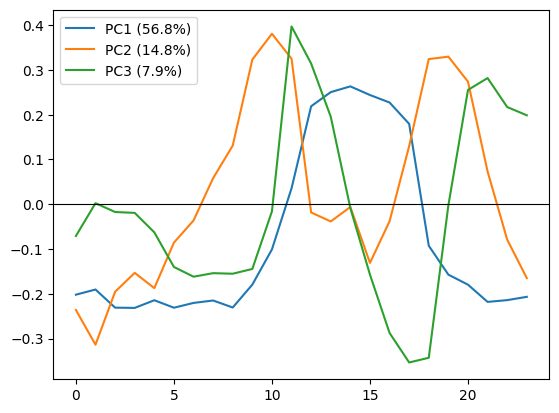

In [23]:
# 1. Pre‑procesar: z‑score por estación y derivar climatología 24h
df = pd.read_csv(csv_hourly, index_col=0, parse_dates=True)                            # rango que quieras
df_z = df.apply(lambda s: (s - s.mean())/s.std(), axis=0)

clim24 = df_z.groupby(df_z.index.hour).mean().T    # 24 cols, nEst rows

# 2. PCA sobre la climatología
X = StandardScaler().fit_transform(clim24)
pca = PCA().fit(X)
loads = pd.DataFrame(pca.components_.T, index=clim24.columns)

# 3. Gráfica sin perder el signo
for i in range(3):
    l = loads.iloc[:, i]
    plt.plot(l.index, l, label=f'PC{i+1} ({pca.explained_variance_ratio_[i]*100:.1f}%)')
    #plt.fill_between(l.index, l - l.std(), l + l.std(), alpha=0.3, color='gray')
plt.axhline(0, lw=.8, c='k')
#dibujar la media y la desviación estándar

plt.legend()
plt.show()

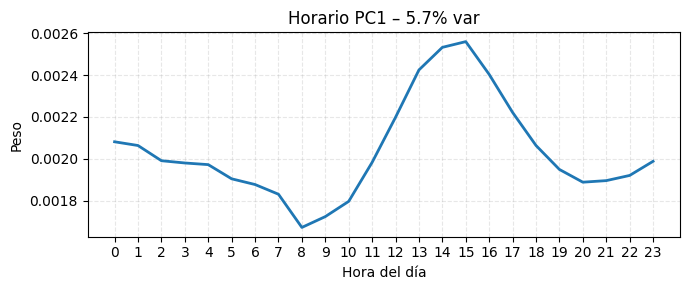

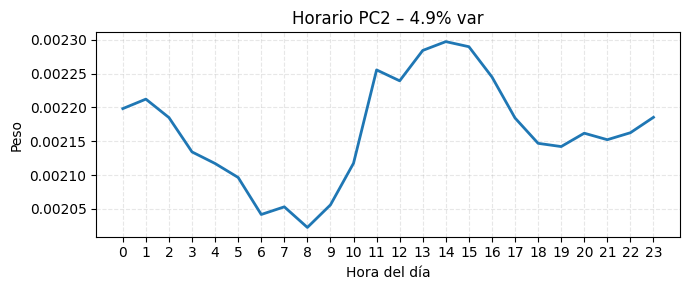

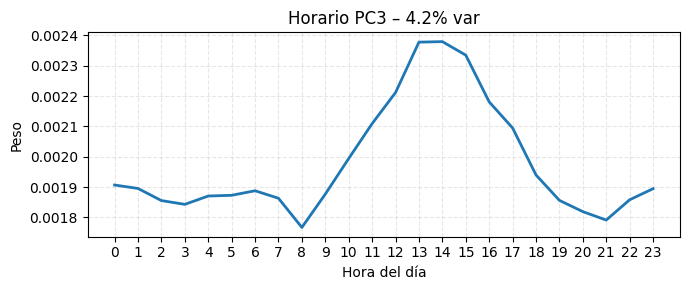

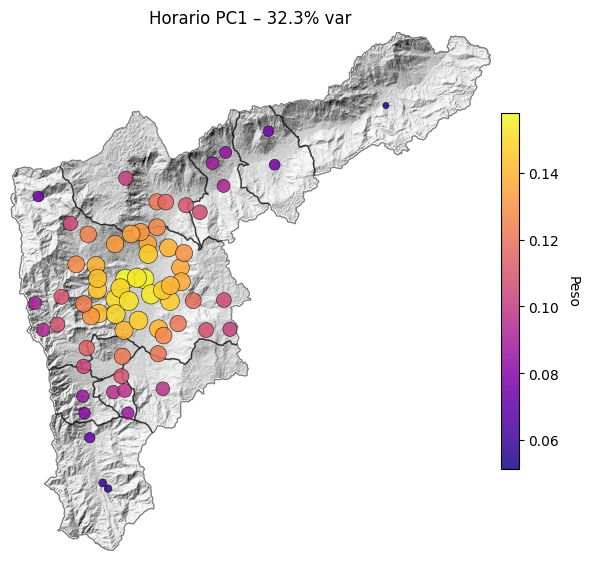

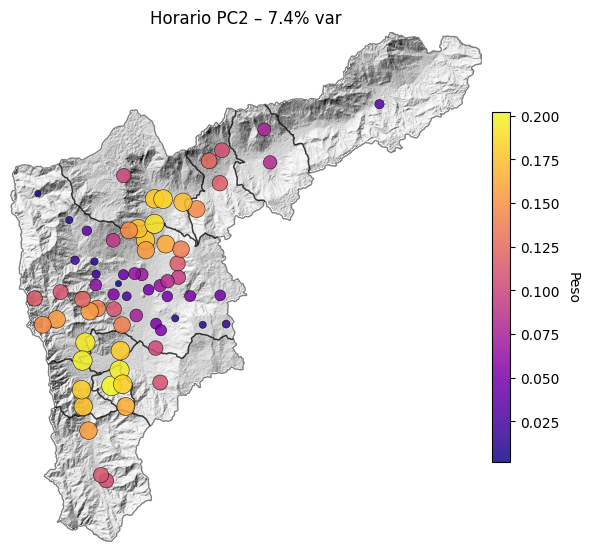

...

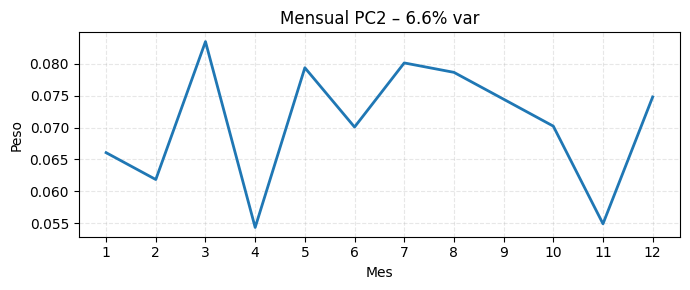

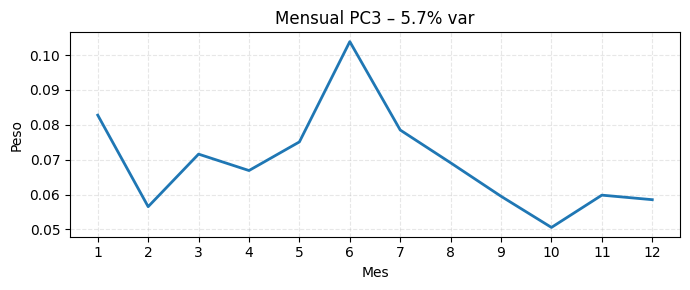

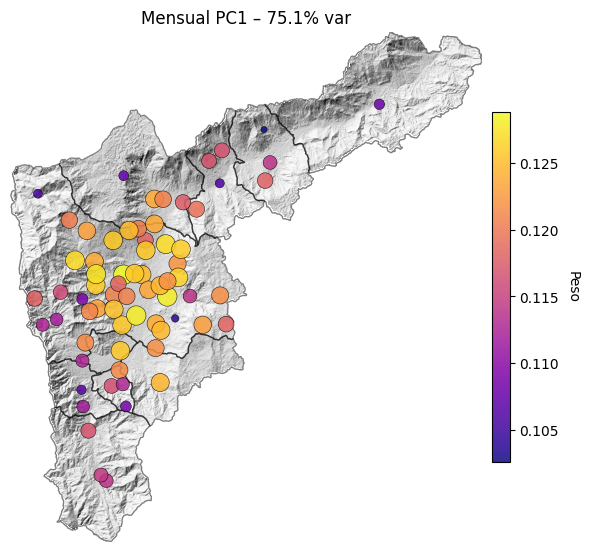

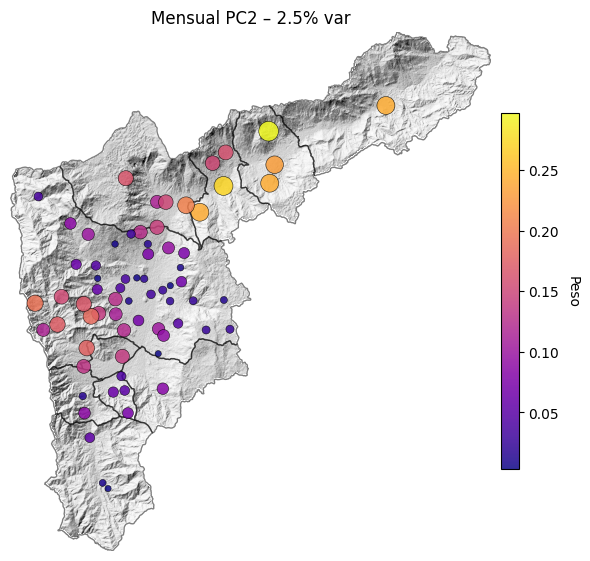

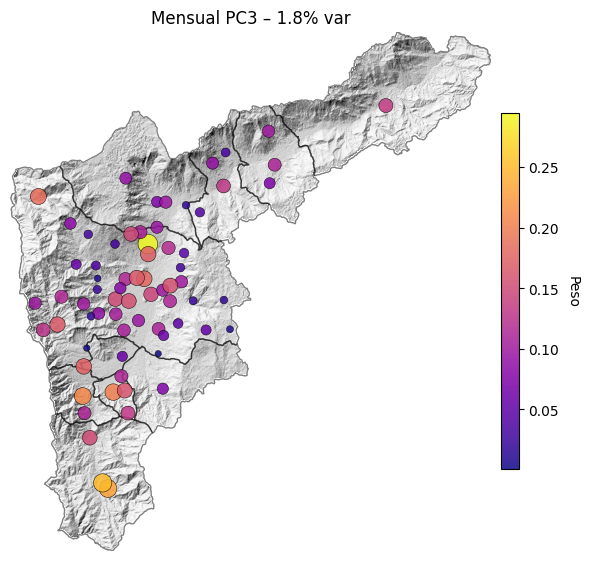

In [33]:
import os, numpy as np, pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import rasterio as rio
from rasterio.plot import show
import matplotlib as mpl
import matplotlib.colors as mcolors
# ───────── rutas y datos ─────────────────────────────────────────
DIR_DATA   = '../../DATA/'
RUTA_COOR  = f'{DIR_DATA}shape_files/'
CSV        = dict(
    horario  = f'{DIR_DATA}all_stations_SIATA_hourly.csv',
    diario   = f'{DIR_DATA}all_stations_SIATA_daily.csv',
    mensual  = f'{DIR_DATA}all_stations_SIATA_monthly.csv'
)

pluvios   = gpd.read_file(RUTA_COOR + 'Est_All.shp').set_index('codigo')
hill_src  = rio.open(RUTA_COOR + 'DEM_west_Hillshade_Clip_r.tif')
hill      = np.where(hill_src.read(1) == hill_src.read(1)[0, 0], np.nan,
                     hill_src.read(1))
AMVA      = gpd.read_file('/home/oisanchezp/Geociencias/shape_files/mpios_amva_qnk.shp')

# ───────── utilidades gráficas ───────────────────────────────────
def tamanios_relativos(x, min_px=20, max_px=200):
    x = (x - x.min()) / (x.max() - x.min())
    return min_px + x * (max_px - min_px)

def plot_temporal_pc(load, scale, var_ratio, pc_lbl):
    tsi = pd.to_datetime(load.index, errors='coerce')
    fig, ax = plt.subplots(figsize=(7,3))

    if scale == 'horario':                       # 24 h
        idx = tsi.hour
        stats = load.groupby(idx).agg(['mean','std'])
        h, m, s = stats.index, stats['mean'], stats['std']
        ax.plot(h, m, lw=2)
        ax.set_xlabel('Hora del día')
        ax.set_xticks(range(0,24,1))

    elif scale == 'diario':
        idx = tsi.dayofyear
        stats = load.groupby(idx).agg(['mean','std'])
        d, m, s = stats.index, stats['mean'], stats['std']
        ax.plot(d, m, lw=2)
        ax.set_xlabel('Día del año')
        ax.set_xticks(range(0,365,30))

    else:                           # mensual
        idx = tsi.month
        stats = load.groupby(idx).agg(['mean','std'])
        mth, m, s = stats.index, stats['mean'], stats['std']
        ax.plot(mth, m, lw=2)
        ax.set_xlabel('Mes')
        ax.set_xticks(range(1,13))

    ax.set_ylabel('Peso')
    ax.set_title(f'{scale.capitalize()} {pc_lbl} – {var_ratio*100:.1f}% var')
    ax.grid(ls='--', alpha=.3)
    plt.tight_layout()

def plot_spatial_pc(load, gdf, scale, var_ratio, pc_lbl):
    
    gdf2 = gdf.copy()
    gdf2['imp'] = load.reindex(gdf2.index).abs()          # intensidad
    ms  = tamanios_relativos(gdf2['imp'].fillna(0))       # tamaño      (20 → 200 px)

    # ── normalizador y mapa de colores ──────────────────────────
    norm = mcolors.Normalize(vmin=gdf2['imp'].min(), vmax=gdf2['imp'].max())
    cmap = mpl.colormaps['plasma']                    # cualquier cmap continuo
    # (los valores más altos → colores cálidos)

    fig, ax = plt.subplots(figsize=(6,6))
    show(hill, transform=hill_src.transform, ax=ax, cmap='Greys_r')
    AMVA.plot(ax=ax, facecolor='none', edgecolor='black', alpha=.5)

    # ── dispersión con tamaño + color ───────────────────────────
    sc = ax.scatter(gdf2.geometry.x, gdf2.geometry.y,
                    s=ms,                                # tamaño
                    c=gdf2['imp'], cmap=cmap, norm=norm, # color
                    edgecolor='k', linewidth=.4, alpha=.85)

    # ── barra de color ──────────────────────────────────────────
    cbar = fig.colorbar(sc, ax=ax, fraction=.035, pad=.02)
    cbar.set_label('Peso', rotation=270, labelpad=15)

    ax.set_title(f'{scale.capitalize()} {pc_lbl} – {var_ratio*100:.1f}% var')
    ax.set_axis_off()
    plt.tight_layout()

# ───────── PCA por escala ────────────────────────────────────────
pluvios.index = pluvios.index.astype(str)
for scale, path_csv in CSV.items():
    df = pd.read_csv(path_csv, index_col=0)

    # 1) PCA temporal (filas = estaciones)
    feats_t = df.T                               # estaciones como filas
    X_t = StandardScaler().fit_transform(feats_t)
    pca_t = PCA(n_components=3, svd_solver='randomized', random_state=0).fit(X_t)
    loads_t = pd.DataFrame(pca_t.components_.T,
                           index=feats_t.columns,
                           columns=['PC1','PC2','PC3'])

    for i, pc in enumerate(loads_t.columns):
        plot_temporal_pc(loads_t[pc].abs(), scale,
                         pca_t.explained_variance_ratio_[i], pc)

    # 2) PCA espacial (filas = tiempos)
    feats_s = df                                 # estaciones = columnas
    X_s = StandardScaler().fit_transform(feats_s)
    pca_s = PCA(n_components=3, svd_solver='randomized', random_state=0).fit(X_s)
    loads_s = pd.DataFrame(pca_s.components_.T,
                           index=feats_s.columns,
                           columns=['PC1','PC2','PC3'])

    hits = loads_s.index.astype(str).intersection(pluvios.index.astype(str))
    gdf_base = pluvios.loc[hits]

    for i, pc in enumerate(loads_s.columns):
        plot_spatial_pc(loads_s.loc[hits, pc], gdf_base,
                        scale, pca_s.explained_variance_ratio_[i], pc)

plt.show()


#### SOLO SERIE HORARIAS LAS PRIMERAS 100 COMPONENTES PRINCIPALES


/tmp/ipykernel_1571937/4247212562.py:22: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(7,3))


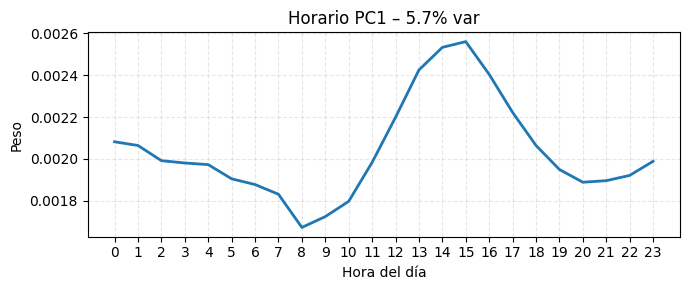

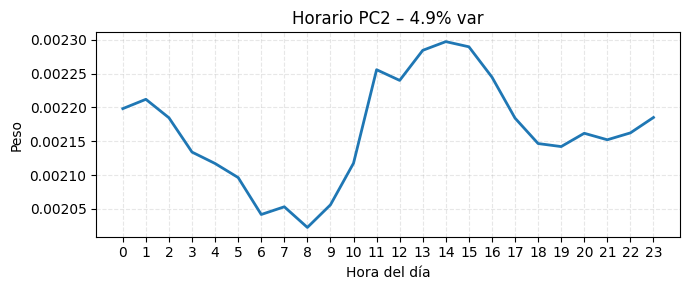

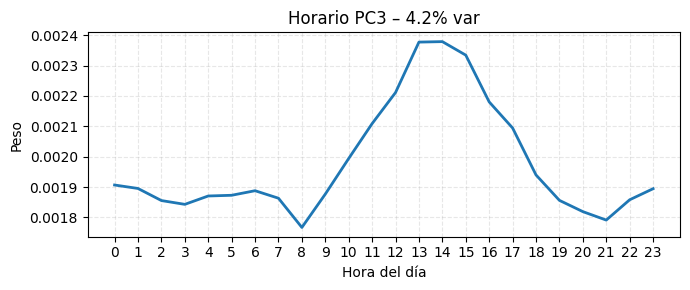

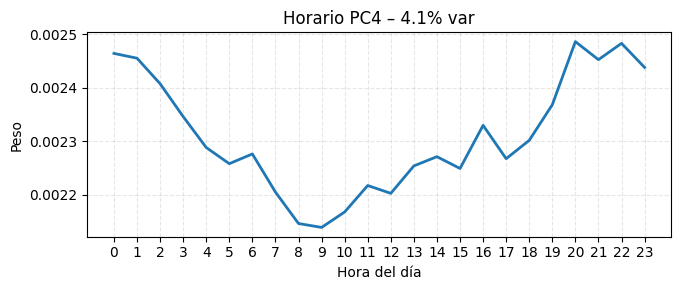

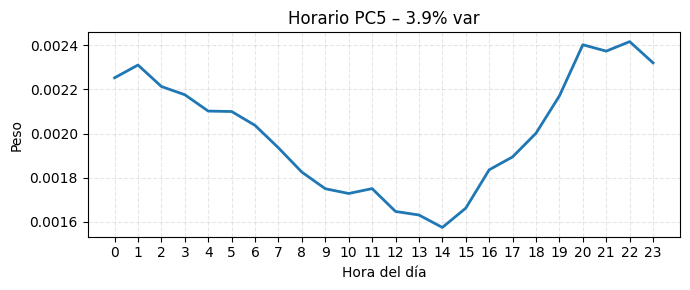

...

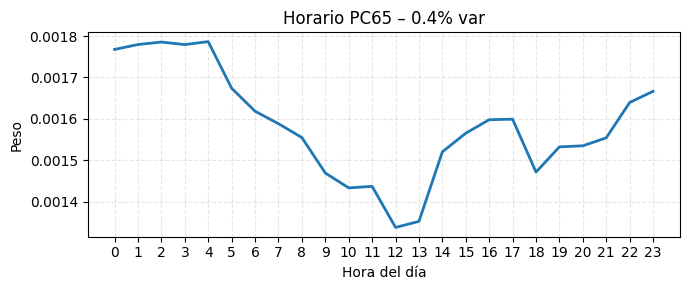

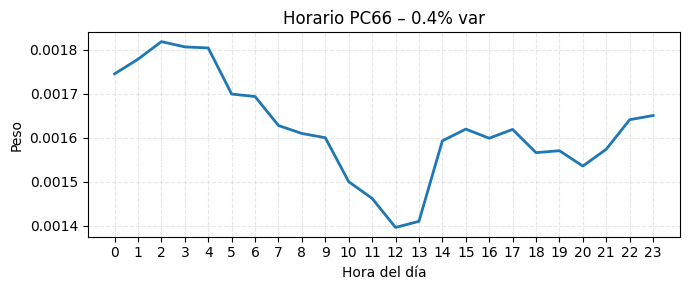

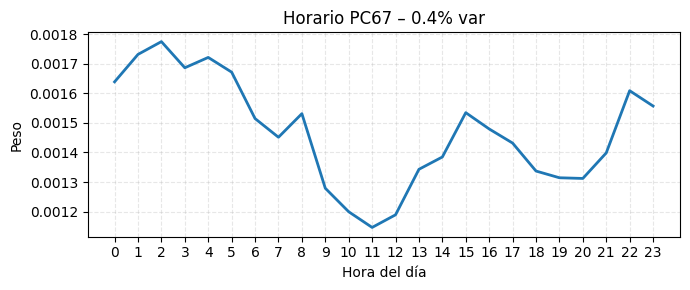

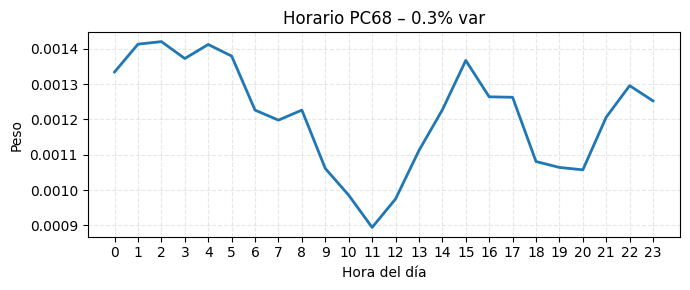

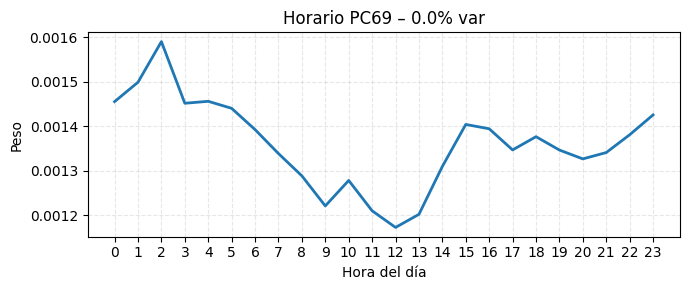

In [7]:
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio as rio
from rasterio.plot import show
import matplotlib as mpl
import matplotlib.colors as mcolors

DIR_DATA   = '../../DATA/'
RUTA_COOR  = f'{DIR_DATA}shape_files/'
CSV        = dict(
    horario  = f'{DIR_DATA}all_stations_SIATA_hourly.csv',
    diario   = f'{DIR_DATA}all_stations_SIATA_daily.csv',
    mensual  = f'{DIR_DATA}all_stations_SIATA_monthly.csv'
)


def plot_temporal_pc(load, scale, var_ratio, pc_lbl):
    tsi = pd.to_datetime(load.index, errors='coerce')
    fig, ax = plt.subplots(figsize=(7,3))

    if scale == 'horario':                       # 24 h
        idx = tsi.hour
        stats = load.groupby(idx).agg(['mean','std'])
        h, m, s = stats.index, stats['mean'], stats['std']
        ax.plot(h, m, lw=2)
        ax.set_xlabel('Hora del día')
        ax.set_xticks(range(0,24,1))

    elif scale == 'diario':
        idx = tsi.dayofyear
        stats = load.groupby(idx).agg(['mean','std'])
        d, m, s = stats.index, stats['mean'], stats['std']
        ax.plot(d, m, lw=2)
        ax.set_xlabel('Día del año')
        ax.set_xticks(range(0,365,30))

    else:                           # mensual
        idx = tsi.month
        stats = load.groupby(idx).agg(['mean','std'])
        mth, m, s = stats.index, stats['mean'], stats['std']
        ax.plot(mth, m, lw=2)
        ax.set_xlabel('Mes')
        ax.set_xticks(range(1,13))

    ax.set_ylabel('Peso')
    ax.set_title(f'{scale.capitalize()} {pc_lbl} – {var_ratio*100:.1f}% var')
    ax.grid(ls='--', alpha=.3)
    plt.tight_layout()
# pluvios   = gpd.read_file(RUTA_COOR + 'Est_All.shp').set_index('codigo')
# hill_src  = rio.open(RUTA_COOR + 'DEM_west_Hillshade_Clip_r.tif')
# hill      = np.where(hill_src.read(1) == hill_src.read(1)[0, 0], np.nan,
#                      hill_src.read(1))
# AMVA      = gpd.read_file('/home/oisanchezp/Geociencias/shape_files/mpios_amva_qnk.shp')


# ── carga de la matriz de lluvia horaria ──────────────────────────────
# cada fila = instante horario (DateTimeIndex)
# cada columna = pluviómetro
# ───────── PCA temporal – primeras 100 componentes (solo escala horaria) ──────
scale  = 'horario'
df     = pd.read_csv(CSV[scale], index_col=0)

# (filas = estaciones / columnas = instantes)
feats_t = df.T
X_t     = StandardScaler().fit_transform(feats_t)

n_pc    = 69
pca_t   = PCA(n_components=n_pc, svd_solver='randomized', random_state=0).fit(X_t)
loads_t = pd.DataFrame(
    pca_t.components_.T,
    index = feats_t.columns,
    columns=[f'PC{i+1}' for i in range(n_pc)]
)

# ── graficar las 100 PC ───────────────────────────────────────────────────────
for i, pc in enumerate(loads_t.columns):
    plot_temporal_pc(
        loads_t[pc].abs(),                   # pesos en valor absoluto
        scale,
        pca_t.explained_variance_ratio_[i],  # % de varianza
        pc                                   
    )



### **CLUSTERING JERÁRQUICO**

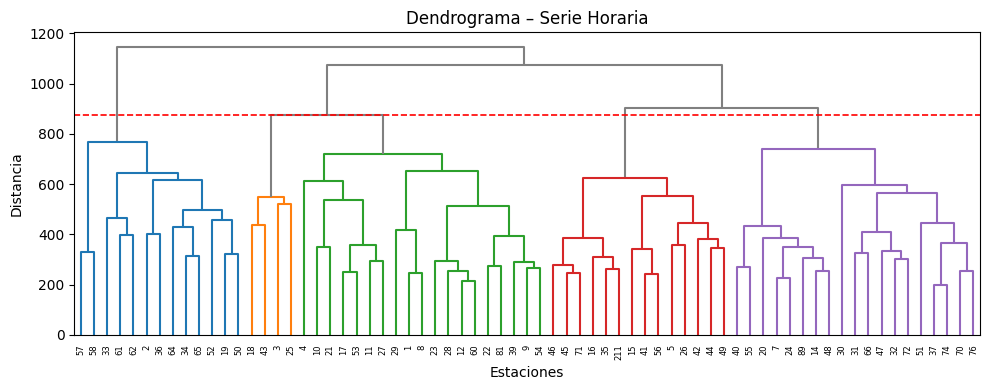

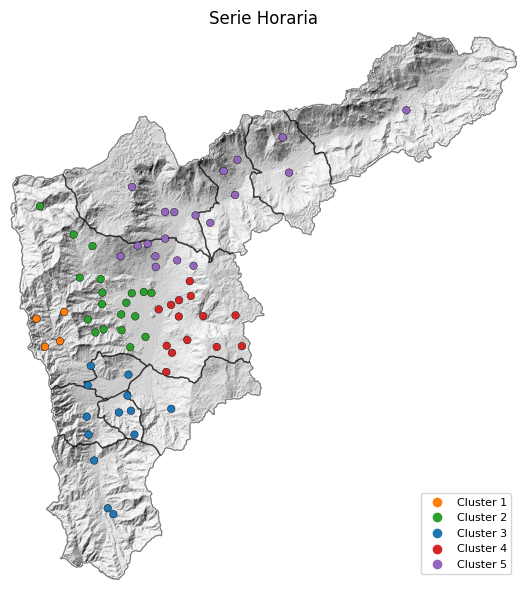

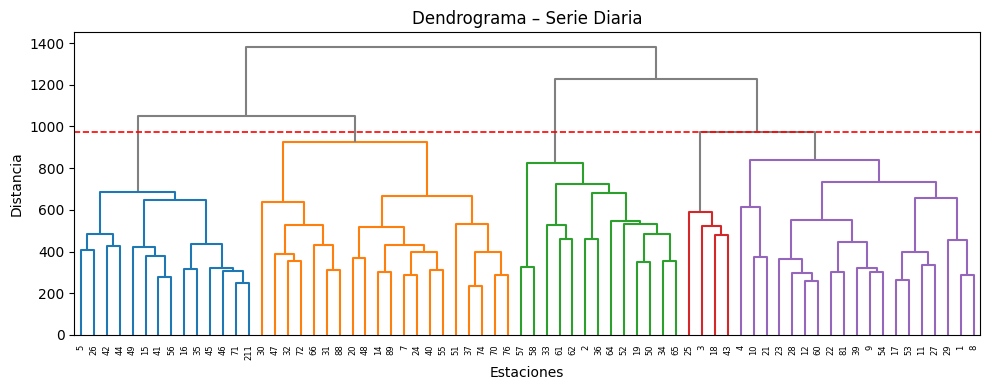

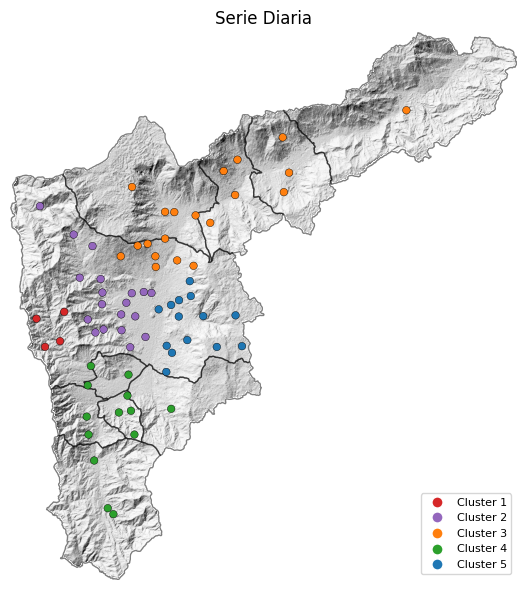

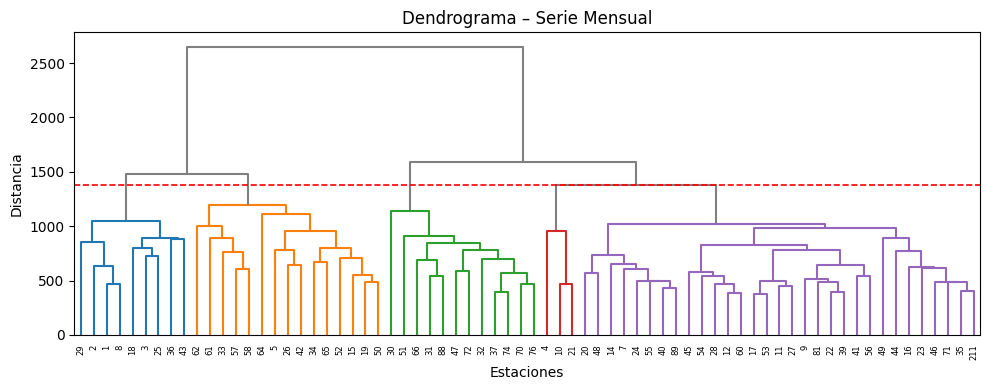

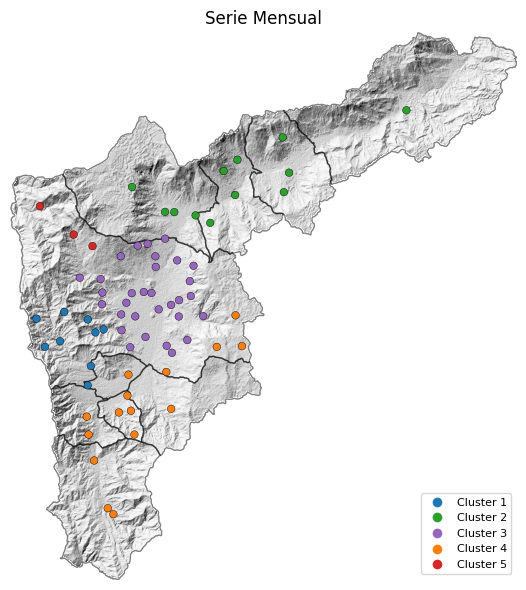

GeoJSON guardado en: ../../DATA/pluvios_clusters.geojson


In [1]:
import os, numpy as np, pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import AgglomerativeClustering
from libpysal.weights import Queen
import rasterio as rio
from rasterio.plot import show
from functools import lru_cache

# ─────────── CONFIGURACIÓN ────────────
dir_data   = '../../DATA/'
ruta_coor  = os.path.join(dir_data, 'shape_files')
csvs       = {
    'horaria': os.path.join(dir_data, 'all_stations_SIATA_hourly.csv'),
    'diaria' : os.path.join(dir_data, 'all_stations_SIATA_daily.csv'),
    'mensual': os.path.join(dir_data, 'all_stations_SIATA_monthly.csv')
}

pluvios  = gpd.read_file(f'{ruta_coor}/Est_All.shp').set_index('codigo')
hill_src = rio.open(f'{ruta_coor}/DEM_west_Hillshade_Clip_r.tif')
hill     = np.where((h := hill_src.read(1)) == h[0, 0], np.nan, h)
AMVA     = gpd.read_file(f'{ruta_coor}/mpios_amva_qnk.shp')

def plot_cluster_map(gdf, color_col, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    show(hill, transform=hill_src.transform, ax=ax, cmap='Greys_r')
    AMVA.plot(ax=ax, facecolor='none', edgecolor='black', alpha=0.5)
    gdf.plot(ax=ax, color=gdf[color_col], edgecolor='k',
             markersize=30, linewidth=.3)

    handles = [Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=c, markersize=8,
                      label=f'Cluster {k}')
               for k, c in sorted(zip(gdf['cluster_opt'].unique(),
                                      gdf.groupby('cluster_opt')[color_col].first()))]
    ax.legend(handles=handles, loc='lower right', fontsize=8)
    ax.set_title(title, fontsize=12)
    ax.set_axis_off()
    plt.tight_layout(); plt.show()

# ─────────── BUCLE PRINCIPAL ───────────
k_opt = 5                                              # número fijo de grupos
palette = [f'C{i}' for i in range(k_opt)]              # C0…C4
cluster_results = {}

for escala, path_csv in csvs.items():
    feats = pd.read_csv(path_csv, index_col=0).T.fillna(0)
    feats.index = feats.index.astype(pluvios.index.dtype)
    gdf   = pluvios.join(feats, how='inner')

    conn  = Queen.from_dataframe(gdf, use_index=True).sparse
    X     = feats.values

    full = AgglomerativeClustering(n_clusters=None, distance_threshold=0,
                                   linkage='ward', connectivity=conn).fit(X)

    # ─── linkage matrix ───
    n = len(full.labels_)
    cnt = np.zeros(full.children_.shape[0])
    for i, merge in enumerate(full.children_):
        cnt[i] = sum((1 if m < n else cnt[m - n]) for m in merge)
    link = np.column_stack([full.children_, full.distances_, cnt]).astype(float)

    # ─── umbral para k_opt ───
    thr = link[-(k_opt-1), 2]

    # etiquetas finales
    labels = fcluster(link, k_opt, 'maxclust')
    colmap = {cl: palette[i] for i, cl in enumerate(np.sort(np.unique(labels)))}

    gdf['cluster_opt'] = labels
    gdf['color_opt']   = gdf['cluster_opt'].map(colmap)

    cluster_results[escala] = pd.Series(labels, index=feats.index)

    # ─── función de color para ramas ───
    @lru_cache(None)
    def nodo_cluster(i):
        if i < n:                       # hoja
            return labels[i]
        l, r = full.children_[i - n]
        cl_l, cl_r = nodo_cluster(l), nodo_cluster(r)
        return cl_l if cl_l == cl_r else None

    def link_color_func(i):
        cl = nodo_cluster(int(i))
        return colmap[cl] if cl is not None else '#808080'

    # ─── dendrograma ───
    sch.set_link_color_palette(palette)
    plt.figure(figsize=(10, 4))
    sch.dendrogram(link, labels=feats.index.astype(str),
                   leaf_rotation=90, leaf_font_size=6,
                   color_threshold=thr, link_color_func=link_color_func)
    plt.axhline(thr, c='r', ls='--', lw=1.2)
    plt.title(f'Dendrograma – Serie {escala.capitalize()}')
    plt.ylabel('Distancia'); plt.xlabel('Estaciones')
    plt.tight_layout(); plt.show()

    # ─── mapa ───
    plot_cluster_map(gdf, 'color_opt',
                     f'Serie {escala.capitalize()}')

# ─────────── GEOJSON DE SALIDA ───────────
col_names = {'horaria': 'horario_cluster',
             'diaria' : 'diario_cluster',
             'mensual': 'mensual_cluster'}

idx_all = sorted(set().union(*[sr.index for sr in cluster_results.values()]))
gdf_out = pluvios.loc[idx_all].copy()

for escala, serie in cluster_results.items():
    gdf_out[col_names[escala]] = serie

out_path = os.path.join(dir_data, 'pluvios_clusters.geojson')
gdf_out.to_file(out_path, driver='GeoJSON')
print(f'GeoJSON guardado en: {out_path}')

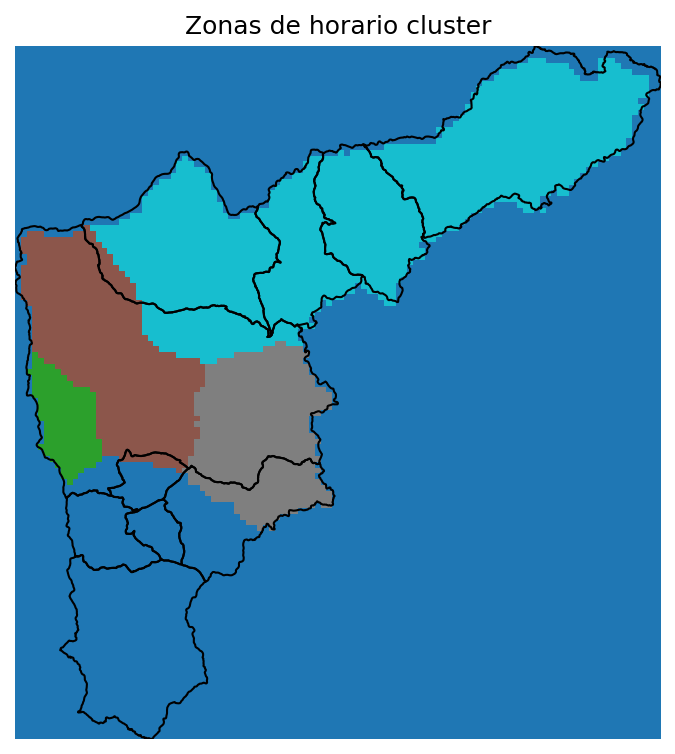

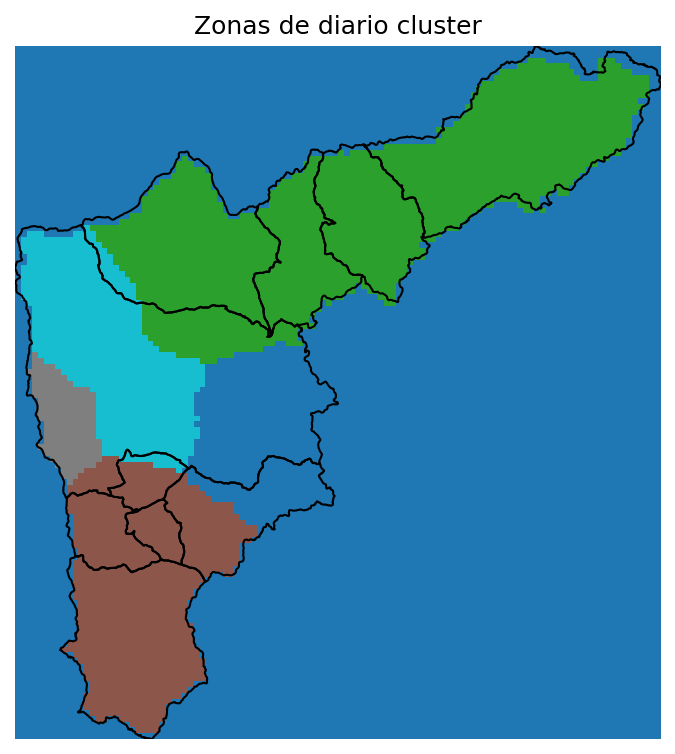

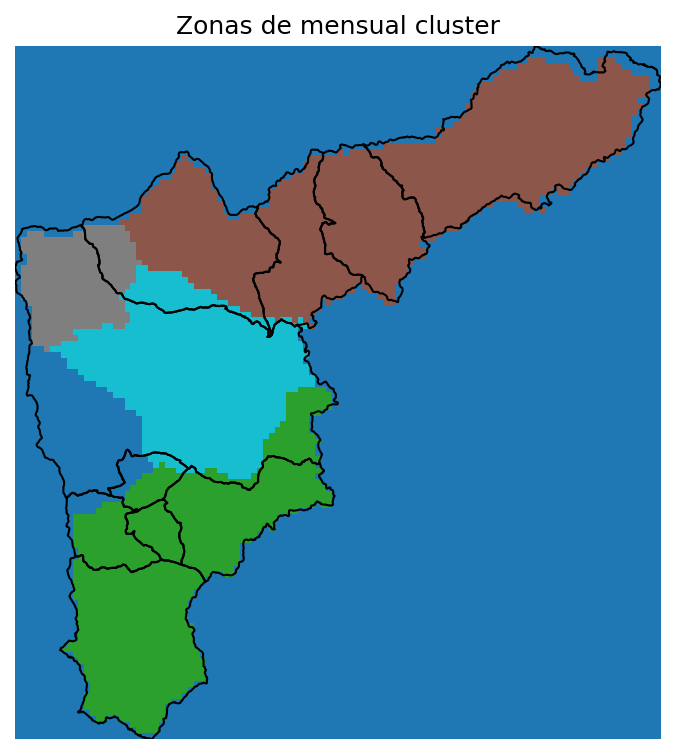

In [21]:
import os
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
from rasterio.transform import from_origin
import rasterio
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# 1. Configuración de rutas y CRS
dir_data = '../../DATA/'
ruta_coor = os.path.join(dir_data, 'shape_files')
CRS_PROJ  = "EPSG:32618"
res        = 500  # resolución en metros

# 2. Carga de datos
cluster_pluvios = (
    gpd.read_file(os.path.join(dir_data, 'pluvios_clusters.geojson'))
       .to_crs(CRS_PROJ)
)
AMVA = (
    gpd.read_file(f'{ruta_coor}/mpios_amva_qnk.shp')
       .to_crs(CRS_PROJ)
)

# 3. Añade elevación del DEM a cada estación
dem_path = os.path.join(ruta_coor, 'dem_am.tif')
with rasterio.open(dem_path) as src:
    elevaciones = []
    for pt in cluster_pluvios.geometry:
        row, col = src.index(pt.x, pt.y)
        elev = src.read(1)[row, col]
        elevaciones.append(elev)
cluster_pluvios['ELEV'] = elevaciones

# 4. Crea grilla dentro de AMVA
minx, miny, maxx, maxy = AMVA.total_bounds
xs = np.arange(minx, maxx + res, res)
ys = np.arange(miny, maxy + res, res)
xx, yy = np.meshgrid(xs, ys)
pts  = np.vstack([xx.ravel(), yy.ravel()]).T

# máscara de puntos dentro de AMVA
union_amva = AMVA.unary_union
mask      = np.array([union_amva.contains(Point(x, y)) for x, y in pts])
grid_pts  = pts[mask]

# extrae elevación en cada punto de la grilla
with rasterio.open(dem_path) as src:
    elev_grid = []
    for x, y in grid_pts:
        row, col = src.index(x, y)
        elev_grid.append(src.read(1)[row, col])
elev_grid = np.array(elev_grid)

# 5. Loop para cada tipo de cluster
# 5. Loop para cada tipo de cluster
for campo in ['horario_cluster', 'diario_cluster', 'mensual_cluster']:
    df = cluster_pluvios.dropna(subset=[campo, 'ELEV'])
    X = np.vstack([
        df.geometry.x,
        df.geometry.y,
        df.ELEV
    ]).T
    y = df[campo].astype(int).values

    # entrena kNN con peso inverso a la distancia
    clf = KNeighborsClassifier(n_neighbors=8, weights='distance')
    clf.fit(X, y)

    # predice sobre la grilla (x, y, elev)
    Xg = np.vstack([grid_pts.T, elev_grid]).T
    pred = clf.predict(Xg)

    # arma el raster y rellena nodata con -9999
    full = np.full(xx.size, -9999, dtype=int)
    full[mask] = pred
    raster = full.reshape(xx.shape)

    # define transform y metadatos, incluyendo nodata
    transform = from_origin(minx, maxy, res, res)
    meta = {
        'driver': 'GTiff',
        'height': raster.shape[0],
        'width': raster.shape[1],
        'count': 1,
        'dtype': 'int32',
        'crs': CRS_PROJ,
        'transform': transform,
        'nodata': -9999
    }

    # escribe el GeoTIFF dentro del contexto abierto
    out_tif = f'{campo}_zones.tif'
    with rasterio.open(out_tif, 'w', **meta) as dst:
        dst.write(raster, 1)

    # visualiza
    plt.figure(figsize=(6,6), dpi=150)
    plt.imshow(
        raster[::-1],
        extent=[minx, maxx, miny, maxy],
        interpolation='nearest',
        cmap='tab10',
        vmin=1, vmax=5
    )
    AMVA.boundary.plot(edgecolor='k', linewidth=1, ax=plt.gca())
    plt.title(f'Zonas de {campo.replace("_", " ")}')
    plt.axis('off')
    plt.show()



Gráficos listos en la carpeta figs_clusters/


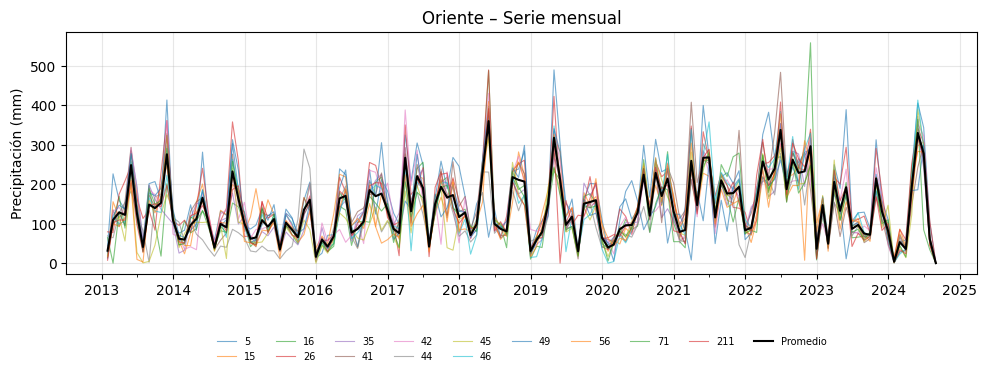

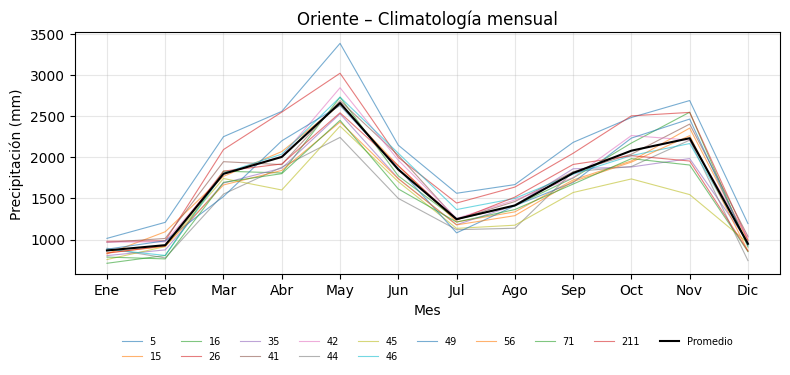

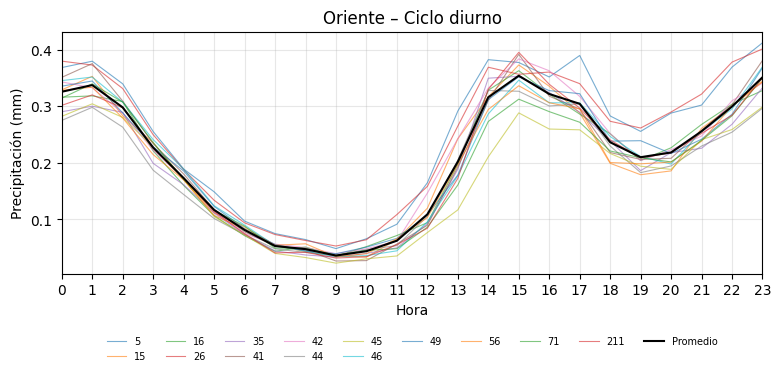

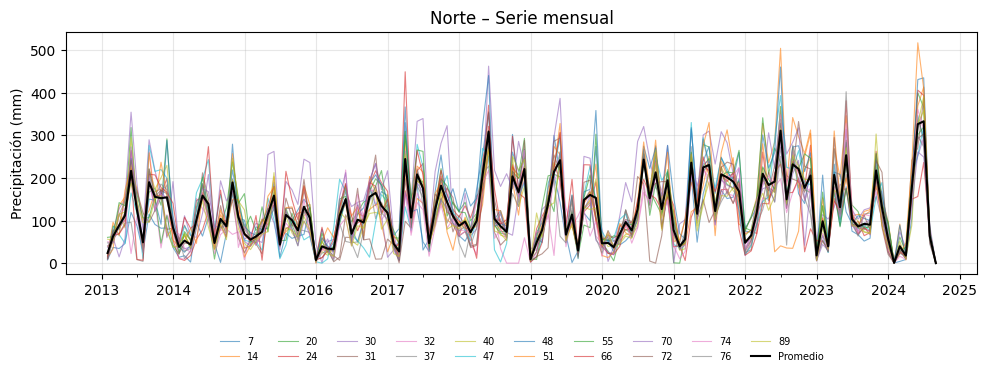

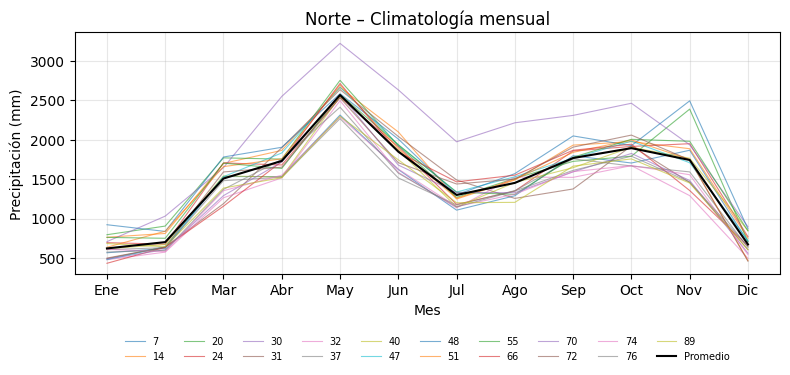

...

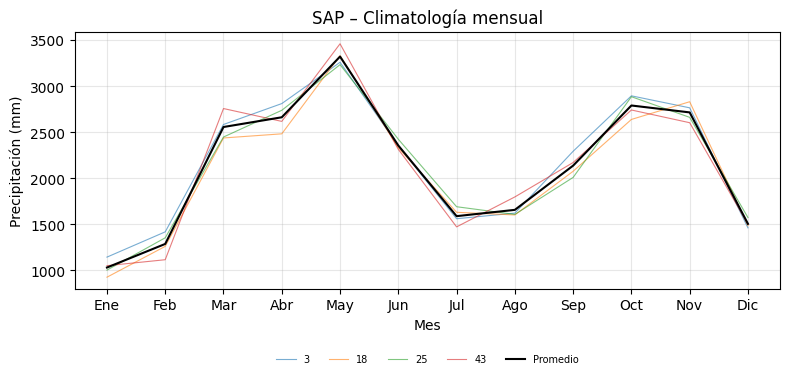

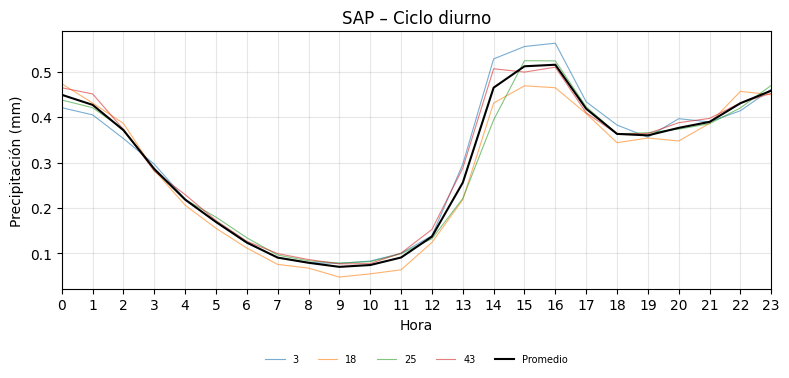

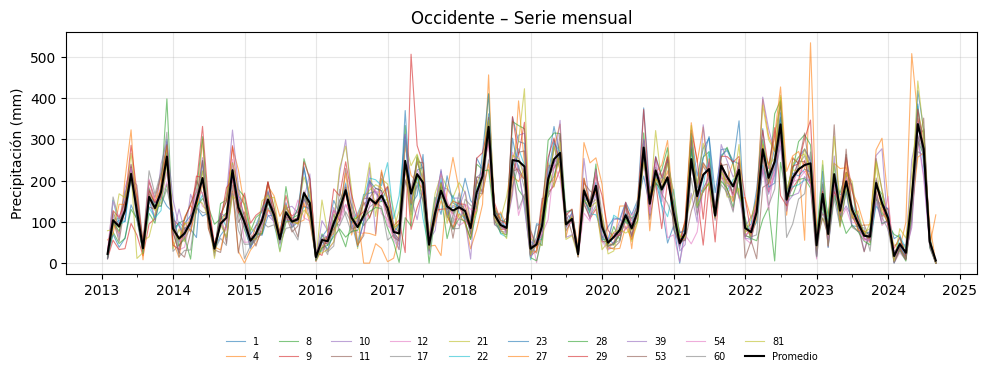

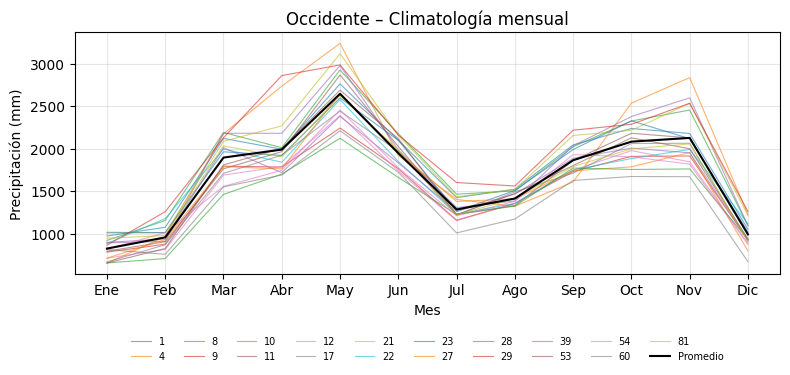

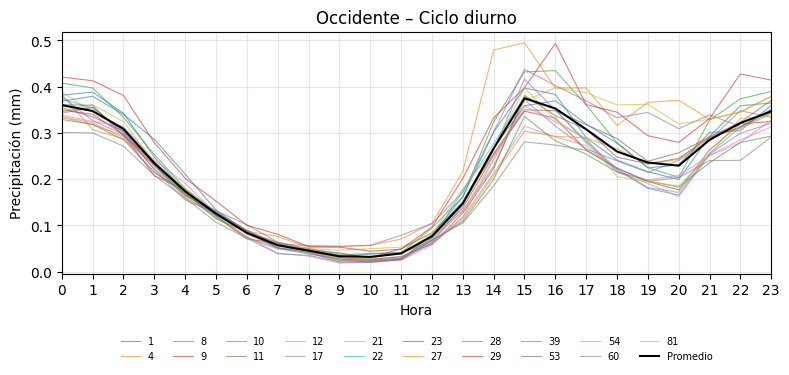

In [ ]:
# ──────────── PREPARA INSUMOS ────────────
import os, numpy as np, pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ─────────── CONFIGURACIÓN ────────────
dir_data   = '../../DATA/'
ruta_coor  = os.path.join(dir_data, 'shape_files')
csvs       = {
    'horaria': os.path.join(dir_data, 'all_stations_SIATA_hourly.csv'),
    'diaria' : os.path.join(dir_data, 'all_stations_SIATA_daily.csv'),
    'mensual': os.path.join(dir_data, 'all_stations_SIATA_monthly.csv')
}

out_path = os.path.join(dir_data, 'pluvios_clusters.geojson')
gdf_out = gpd.read_file(out_path)

csv_h   = csvs['horaria']       # (fecha‑hora, estación…)   mm h‑1
csv_d   = csvs['diaria']        # (fecha, estación…)
csv_m   = csvs['mensual']       # (fecha‑mes, estación…)

df_h = pd.read_csv(csv_h, index_col=0, parse_dates=True)   # filas = timestamps
df_d = pd.read_csv(csv_d, index_col=0, parse_dates=True)
df_m = pd.read_csv(csv_m, index_col=0, parse_dates=True)

# ──────────── FUNCIONES AUXILIARES ────────────
def _plot_mean(ax, x, mean, **kw):
    ax.plot(x, mean, lw=1.5, **kw)

def _pretty(ax, title, xlab, ylab):
    ax.set(title=title, xlabel=xlab, ylabel=ylab)
    ax.grid(alpha=.3)

    handles, labels = ax.get_legend_handles_labels()
    # ‑‑ “Promedio” al final
    if 'Promedio' in labels:
        idx = labels.index('Promedio')
        handles.append(handles.pop(idx))
        labels.append(labels.pop(idx))

    ax.legend(handles, labels,
              loc='upper center',
              bbox_to_anchor=(0.5, -0.22),   # suficiente espacio para 2 filas
              ncol=10,                       # 15 columnas  →  2 filas máx. 30 items
              frameon=False,
              fontsize=7)
    plt.tight_layout()

# nombres de cluster
cluster_names = {1: 'Oriente',
                 2: 'Norte',
                 3: 'Sur',
                 4: 'SAP',
                 5: 'Occidente'}

# cluster_names = {1: 'Oriente',
#                  2: 'Norte',
#                  3: 'Sur',
#                  4: 'SAP',
#                  5: 'Occidente'}

# ──────────── AJUSTES SOLICITADOS ────────────
def graficos_cluster(cid, estaciones, df_m, df_d, df_h,
                     out_dir='figs_clusters'):
    os.makedirs(out_dir, exist_ok=True)

    estaciones = [int(e) for e in estaciones if int(e) != 88]
    est_h      = [e for e in estaciones if str(e) in df_h.columns]

    # ───────── 1) serie mensual ─────────
    df_m = df_m.rename(columns={c: int(c) for c in df_m.columns})
    dat  = df_m[estaciones]['2013':'2024']
    fig, ax = plt.subplots(figsize=(10, 4))
    for st in estaciones:
        ax.plot(dat.index, dat[st], lw=.8, alpha=.6, label=str(st))
    _plot_mean(ax, dat.index, dat.mean(1), color='black', label='Promedio')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 7]))
    _pretty(ax, f'{cluster_names[cid]} – Serie mensual', '', 'Precipitación (mm)')

    # ───────── 2) climatología mensual (diario) ─────────
    df_d = df_d.rename(columns={c: int(c) for c in df_d.columns})
    dsel = df_d[estaciones]['2013':'2024']
    mean_m = dsel.groupby(dsel.index.month).sum().mean(1)
    meses = np.arange(1, 13)
    fig, ax = plt.subplots(figsize=(8, 4))
    for st in estaciones:
        ax.plot(meses,
                dsel[st].groupby(dsel.index.month).sum(),
                lw=.8, alpha=.6, label=str(st))
    _plot_mean(ax, meses, mean_m, color='black', label='Promedio')
    ax.set_xticks(meses)
    ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
    _pretty(ax, f'{cluster_names[cid]} – Climatología mensual', 'Mes', 'Precipitación (mm)')

    # ───────── 3) climatología horaria ─────────
    if est_h:
        df_h = df_h.rename(columns={c: int(c) for c in df_h.columns})
        hdat = df_h[est_h]
        mean_h = hdat.groupby(hdat.index.hour).mean().mean(1)
        horas = np.arange(24)
        fig, ax = plt.subplots(figsize=(8, 4))
        for st in est_h:
            ax.plot(horas,
                    hdat[st].groupby(hdat.index.hour).mean(),
                    lw=.8, alpha=.6, label=str(st))
        _plot_mean(ax, horas, mean_h, color='black', label='Promedio')
        ax.set_xticks(horas); ax.set_xlim(0, 23)
        _pretty(ax, f'{cluster_names[cid]} – Ciclo diurno', 'Hora', 'Precipitación (mm)')

# ──────────── RECORRE CLUSTERS ────────────
for cid in sorted(gdf_out['diario_cluster'].unique()):
    ests = gdf_out.query('diario_cluster == @cid').codigo.tolist()
    graficos_cluster(cid, ests, df_m, df_d, df_h)

print('Gráficos listos en la carpeta figs_clusters/')



Generando gráficos para el cluster 1..Oriente
Generando gráficos para el cluster 2..Norte
Generando gráficos para el cluster 3..Sur
Generando gráficos para el cluster 4..SAP
Generando gráficos para el cluster 5..Occidente
Gráficos listos en la carpeta figs_clusters/


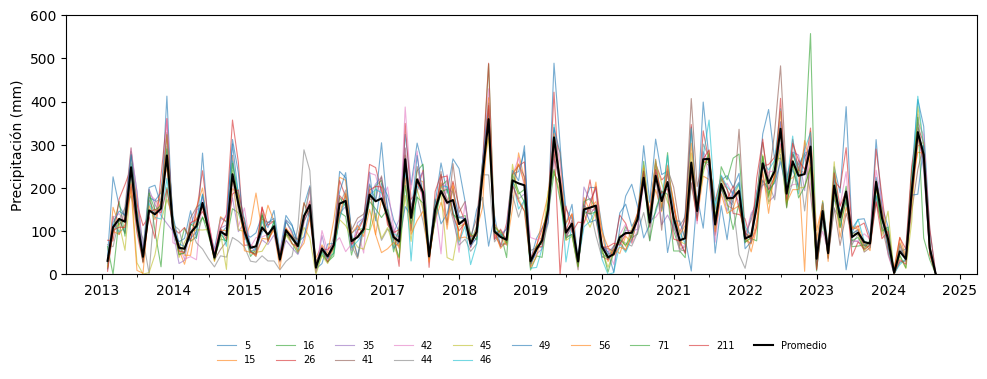

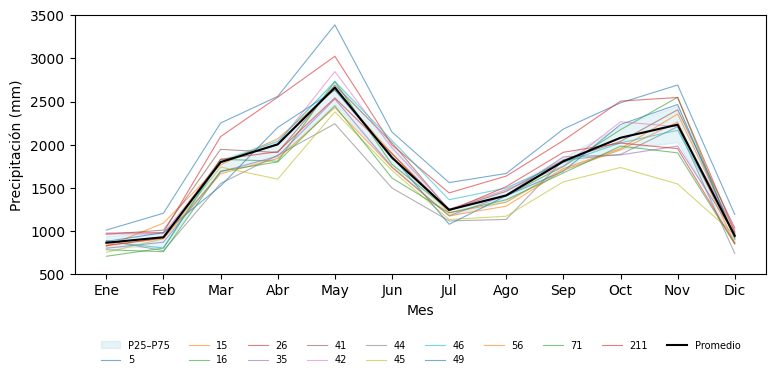

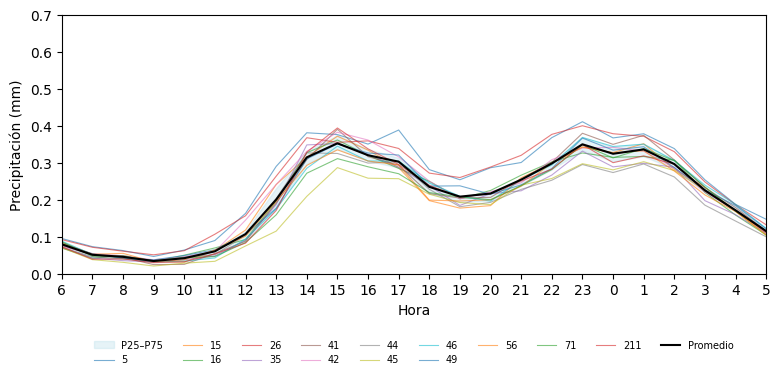

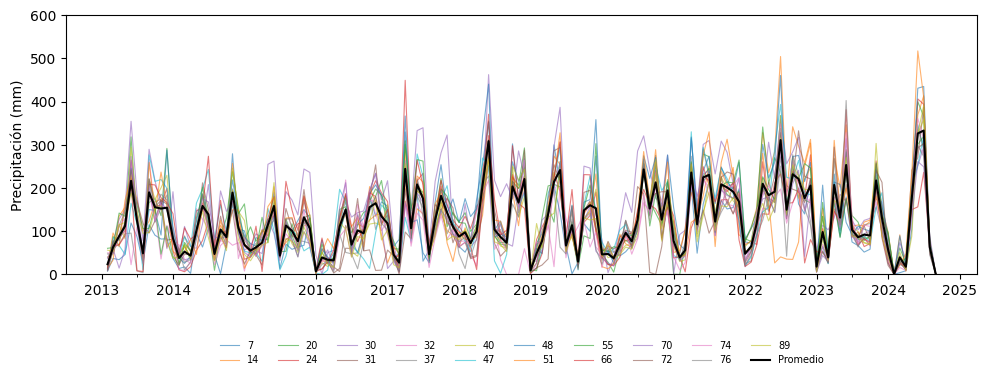

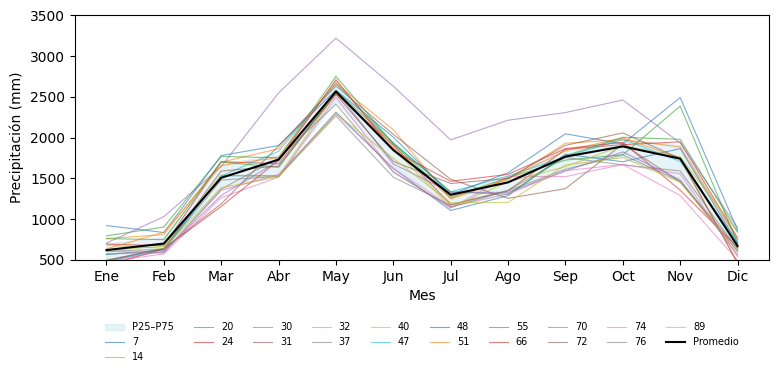

...

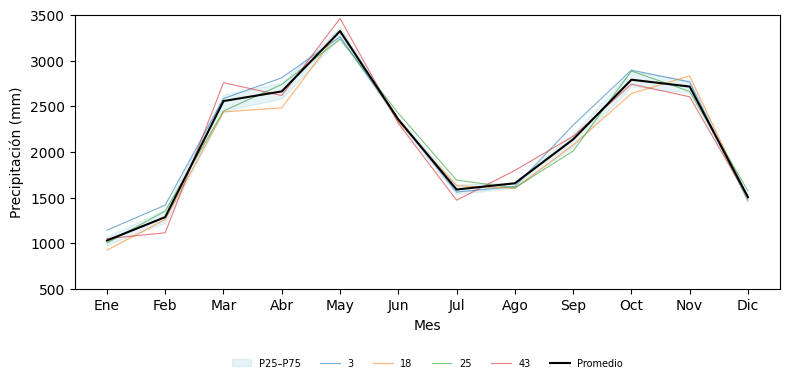

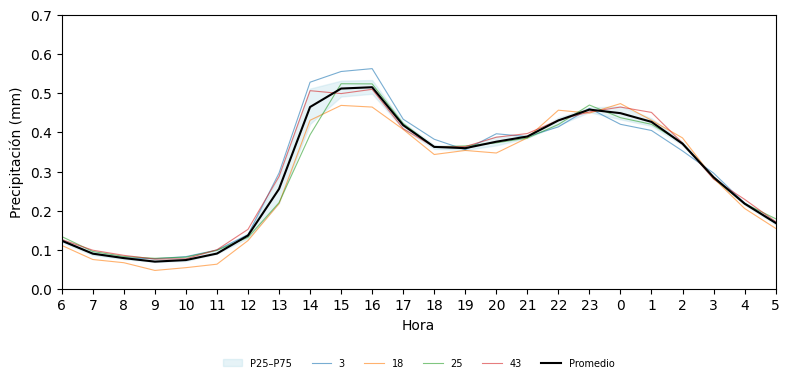

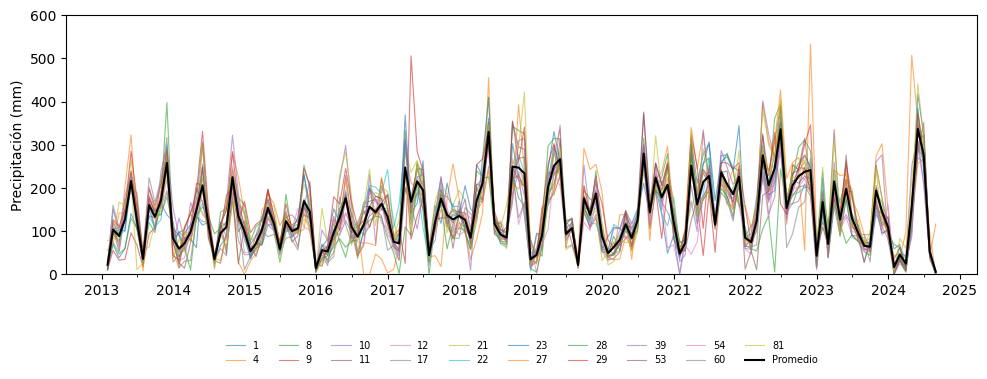

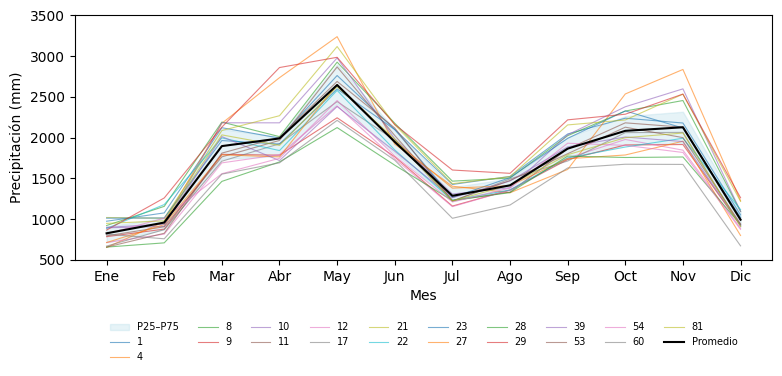

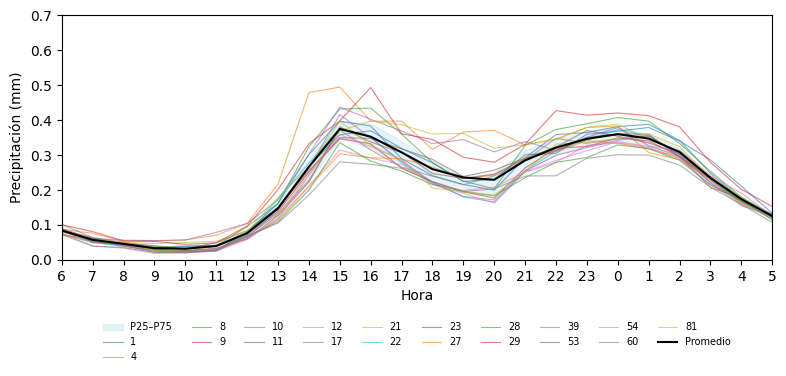

In [2]:
# ──────────── PREPARA INSUMOS ────────────
import os, numpy as np, pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ─────────── CONFIGURACIÓN ────────────
dir_data   = '../../DATA/'
ruta_coor  = os.path.join(dir_data, 'shape_files')
csvs       = {
    'horaria': os.path.join(dir_data, 'all_stations_SIATA_hourly.csv'),
    'diaria' : os.path.join(dir_data, 'all_stations_SIATA_daily.csv'),
    'mensual': os.path.join(dir_data, 'all_stations_SIATA_monthly.csv')
}

out_path = os.path.join(dir_data, 'pluvios_clusters.geojson')
gdf_out = gpd.read_file(out_path)

csv_h   = csvs['horaria']       # (fecha‑hora, estación…)   mm h‑1
csv_d   = csvs['diaria']        # (fecha, estación…)
csv_m   = csvs['mensual']       # (fecha‑mes, estación…)

df_h = pd.read_csv(csv_h, index_col=0, parse_dates=True)   # filas = timestamps
df_d = pd.read_csv(csv_d, index_col=0, parse_dates=True)
df_m = pd.read_csv(csv_m, index_col=0, parse_dates=True)

# ──────────── FUNCIONES AUXILIARES ────────────
def _plot_mean(ax, x, mean, **kw):
    ax.plot(x, mean, lw=1.5, **kw)

def _pretty(ax, title, xlab, ylab):
    # -- si se pasa '' o None no se muestra título
    if title:                       # ← NUEVO
        ax.set_title(title)         # ← NUEVO

    ax.set(xlabel=xlab, ylabel=ylab)
    #ax.grid(alpha=.3)

    handles, labels = ax.get_legend_handles_labels()
    if 'Promedio' in labels:        # “Promedio” al final
        idx = labels.index('Promedio')
        handles.append(handles.pop(idx))
        labels.append(labels.pop(idx))

    ax.legend(handles, labels,
              loc='upper center',
              bbox_to_anchor=(0.5, -0.22),
              ncol=10,
              frameon=False,
              fontsize=7)
    plt.tight_layout()

# nombres de cluster
cluster_names = {1: 'Oriente',
                 2: 'Norte',
                 3: 'Sur',
                 4: 'SAP',
                 5: 'Occidente'}

# cluster_names = {1: 'Oriente',
#                  2: 'Norte',
#                  3: 'Sur',
#                  4: 'SAP',
#                  5: 'Occidente'}

# ──────────── AJUSTES SOLICITADOS ────────────
def graficos_cluster(cid, estaciones, df_m, df_d, df_h,
                     out_dir='figs_clusters'):
    
    print(f'Generando gráficos para el cluster {cid}..{cluster_names[cid]}')
    os.makedirs(out_dir, exist_ok=True)

    estaciones = [int(e) for e in estaciones if int(e) != 88]
    est_h      = [e for e in estaciones if str(e) in df_h.columns]

    # ───────── 1) serie mensual ─────────
    df_m = df_m.rename(columns={c: int(c) for c in df_m.columns})
    dat  = df_m[estaciones]['2013':'2024']
    fig, ax = plt.subplots(figsize=(10, 4))
    for st in estaciones:
        ax.plot(dat.index, dat[st], lw=.8, alpha=.6, label=str(st))
    _plot_mean(ax, dat.index, dat.mean(1), color='black', label='Promedio')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.set_ylim(0, 600)
    _pretty(ax, '', '', 'Precipitación (mm)')          # serie mensual
    fig.savefig(os.path.join(out_dir, f'cluster_{cid}_serie_mensual.png'), dpi=100)

    # ───────── 2) climatología mensual (diario) ─────────
    # ───────── 2) climatología mensual (diario) ─────────
    df_d  = df_d.rename(columns={c: int(c) for c in df_d.columns})
    dsel  = df_d[estaciones]['2013':'2024']

    # ── matriz (filas = mes, columnas = estación) ──
    gmes  = dsel.groupby(dsel.index.month).sum()

    mean_m = gmes.mean(1)                 # promedio
    p25_m  = gmes.quantile(.25, axis=1)   # P25
    p75_m  = gmes.quantile(.75, axis=1)   # P75

    meses = np.arange(1, 13)
    fig, ax = plt.subplots(figsize=(8, 4))

    # IQR (color azul claro)
    ax.fill_between(meses, p25_m, p75_m,
                    color='lightblue', alpha=.3, label='P25–P75')

    # Curva de cada estación
    for st in estaciones:
        ax.plot(meses, gmes[st], lw=.8, alpha=.6, label=str(st))

    # Promedio del cluster
    _plot_mean(ax, meses, mean_m, color='black', label='Promedio')

    ax.set_xticks(meses)
    ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                        'Jul','Ago','Sep','Oct','Nov','Dic'])
    ax.set_ylim(500, 3500)
    _pretty(ax, '', 'Mes', 'Precipitación (mm)')
    fig.savefig(os.path.join(out_dir, f'cluster_{cid}_clim_mensual.png'), dpi=100)



    # ───────── 3) climatología horaria ─────────
    # ───────── 3) ciclo diurno (06-05) ─────────
# ───────── 3) ciclo diurno (06-05) ─────────
    if est_h:
        df_h  = df_h.rename(columns={c: int(c) for c in df_h.columns})
        hdat  = df_h[est_h]

        # 24 × n_estaciones (prom. diario de cada estación)
        ghor  = hdat.groupby(hdat.index.hour).mean()

        # Orden deseado 06-23, 00-05
        horas_plot = np.roll(np.arange(24), -6)
        ghor  = ghor.reindex(horas_plot)

        mean_h = ghor.mean(1)                # promedio
        p25_h  = ghor.quantile(.25, axis=1)  # P25
        p75_h  = ghor.quantile(.75, axis=1)  # P75

        fig, ax = plt.subplots(figsize=(8, 4))

        # IQR en azul claro
        ax.fill_between(range(24), p25_h, p75_h,
                        color='lightblue', alpha=.3, label='P25–P75')

        # Curva de cada estación
        for st in est_h:
            ax.plot(range(24), ghor[st], lw=.8, alpha=.6, label=str(st))

        # Promedio del cluster
        _plot_mean(ax, range(24), mean_h, color='black', label='Promedio')

        ax.set_xticks(range(24))
        ax.set_xticklabels(horas_plot)
        ax.set_xlim(0, 23)
        ax.set_ylim(0, 0.7)
        _pretty(ax, '', 'Hora', 'Precipitación (mm)')
        fig.savefig(os.path.join(out_dir, f'cluster_{cid}_ciclo_diurno.png'), dpi=100)

# ──────────── RECORRE CLUSTERS ────────────
for cid in sorted(gdf_out['diario_cluster'].unique()):
    ests = gdf_out.query('diario_cluster == @cid').codigo.tolist()
    graficos_cluster(cid, ests, df_m, df_d, df_h)

print('Gráficos listos en la carpeta figs_clusters/')


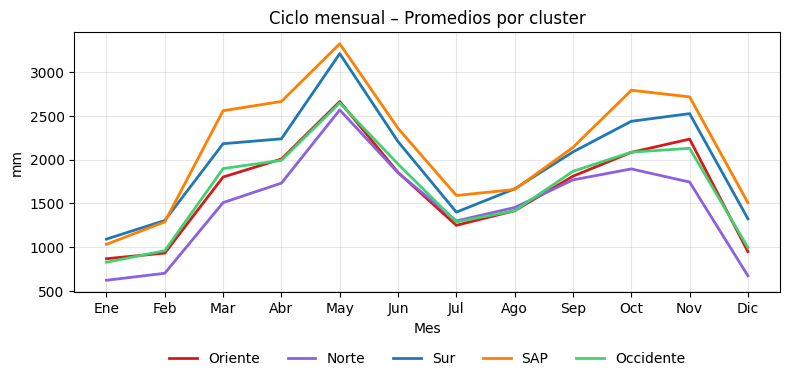

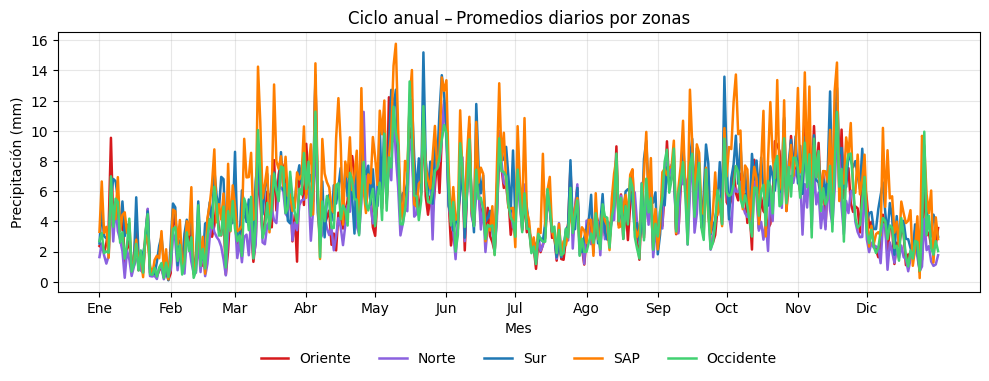

In [9]:
# ──────────── PREPARA INSUMOS ────────────
import os, numpy as np, pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ─────────── CONFIGURACIÓN ────────────
dir_data   = '../../DATA/'
ruta_coor  = os.path.join(dir_data, 'shape_files')
csvs       = {
    'horaria': os.path.join(dir_data, 'all_stations_SIATA_hourly.csv'),
    'diaria' : os.path.join(dir_data, 'all_stations_SIATA_daily.csv'),
    'mensual': os.path.join(dir_data, 'all_stations_SIATA_monthly.csv')
}

out_path = os.path.join(dir_data, 'pluvios_clusters.geojson')
gdf_out = gpd.read_file(out_path)

csv_h   = csvs['horaria']       # (fecha‑hora, estación…)   mm h‑1
csv_d   = csvs['diaria']        # (fecha, estación…)
csv_m   = csvs['mensual']       # (fecha‑mes, estación…)

df_h = pd.read_csv(csv_h, index_col=0, parse_dates=True)   # filas = timestamps
df_d = pd.read_csv(csv_d, index_col=0, parse_dates=True)
df_m = pd.read_csv(csv_m, index_col=0, parse_dates=True)


# ───────── CONFIGURACIÓN GENERAL ─────────
meses  = np.arange(1, 13)
horas  = np.arange(24)
colores = {3: '#1f78b4',
           4: '#ff7f00',
           5: '#41d171',
           1: '#d7191c',
           2: '#8b61df'}
cluster_names = {1: 'Oriente',
                 2: 'Norte',
                 3: 'Sur',
                 4: 'SAP',
                 5: 'Occidente'}

# ───────── PREPARA DATAFRAMES ─────────
df_d = df_d.rename(columns={c: int(c) for c in df_d.columns})
df_h = df_h.rename(columns={c: int(c) for c in df_h.columns})
df_d = df_d.rename(columns={c: int(c) for c in df_d.columns})

# ───────── CICLO MENSUAL (medias de cluster) ─────────
fig, ax = plt.subplots(figsize=(8,4))
for cid in sorted(cluster_names):
    ests = [int(e) for e in gdf_out.query('diario_cluster == @cid').codigo if int(e)!=88]
    mean_m = df_d[ests]['2013':'2024'].groupby(df_d.index.month).sum().mean(1)
    ax.plot(meses, mean_m, lw=2, color=colores[cid], label=cluster_names[cid])
ax.set_xticks(meses)
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
ax.set_xlabel('Mes'); ax.set_ylabel('mm'); ax.grid(alpha=.3)
ax.legend(ncol=5, frameon=False, loc='upper center', bbox_to_anchor=(0.5,-0.18))
ax.set_title('Ciclo mensual – Promedios por cluster')
plt.tight_layout()


# ───────── CICLO ANUAL (medias diarias por cluster) ─────────
# 1) quita 29‑Feb para todos los años
mask = ~((df_d.index.month == 2) & (df_d.index.day == 29))
df_d_clean = df_d.loc[mask]

fig, ax = plt.subplots(figsize=(10,4))

for cid in sorted(cluster_names):
    ests = [int(e) for e in gdf_out.query('diario_cluster == @cid').codigo
            if int(e) != 88]

    if not ests:
        continue

    mean_doy = (df_d_clean[ests]['2013':'2024']
                .groupby(df_d_clean.index.dayofyear)   # 1‑365
                .mean()                                # promedio temporal
                .mean(axis=1))                         # promedio espacial

    ax.plot(mean_doy.index, mean_doy.values,            # usa su propio índice
            lw=1.8, color=colores[cid], label=cluster_names[cid])

# marcas al inicio de cada mes (año no bisiesto)
month_starts = pd.date_range('2021-01-01','2021-12-01',freq='MS').dayofyear
ax.set_xticks(month_starts)
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])

ax.set_xlabel('Mes'); ax.set_ylabel('Precipitación (mm)'); ax.grid(alpha=.3)
ax.legend(ncol=5, frameon=False,
          loc='upper center', bbox_to_anchor=(0.5, -0.18))
ax.set_title('Ciclo anual – Promedios diarios por zonas')
plt.tight_layout()

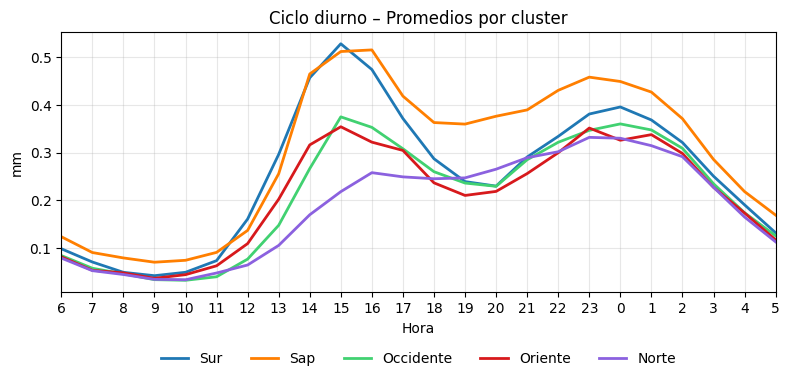

In [10]:
# ──────────── PREPARA INSUMOS ────────────
import os, numpy as np, pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ─────────── CONFIGURACIÓN ────────────
dir_data   = '../../DATA/'
ruta_coor  = os.path.join(dir_data, 'shape_files')
csvs       = {
    'horaria': os.path.join(dir_data, 'all_stations_SIATA_hourly.csv'),
    'diaria' : os.path.join(dir_data, 'all_stations_SIATA_daily.csv'),
    'mensual': os.path.join(dir_data, 'all_stations_SIATA_monthly.csv')
}

out_path = os.path.join(dir_data, 'pluvios_clusters.geojson')
gdf_out = gpd.read_file(out_path)

csv_h   = csvs['horaria']       # (fecha‑hora, estación…)   mm h‑1
csv_d   = csvs['diaria']        # (fecha, estación…)
csv_m   = csvs['mensual']       # (fecha‑mes, estación…)

df_h = pd.read_csv(csv_h, index_col=0, parse_dates=True)   # filas = timestamps
df_d = pd.read_csv(csv_d, index_col=0, parse_dates=True)
df_m = pd.read_csv(csv_m, index_col=0, parse_dates=True)

df_h.columns = df_h.columns.astype(int)   # ahora son enteros
# ───────── CONFIGURACIÓN GENERAL ─────────
meses  = np.arange(1, 13)
horas  = np.arange(24)
colores = {1: '#1f78b4',
           2: '#ff7f00',
           3: '#41d171',
           4: '#d7191c',
           5: '#8b61df'}
cluster_names = {1: 'Sur',
                 2: 'Sap',
                 3: 'Occidente',
                 4: 'Oriente',
                 5: 'Norte'}


# ───────── CICLO DIURNO (medias de cluster) ─────────
# ───────── CICLO DIURNO (medias de cluster) ─────────
fig, ax = plt.subplots(figsize=(8,4))

horas_plot = np.roll(np.arange(24), -6)   # 06,07,…,23,00,01,…,05  ← NUEVO

for cid in sorted(cluster_names):
    ests = [int(e) for e in
            gdf_out.query('horario_cluster == @cid').codigo
            if int(e) != 88 and int(e) in df_h.columns]

    if not ests:
        continue

    # media por hora (0-23)
    mean_h = (df_h[ests]
              .groupby(df_h.index.hour)
              .mean()
              .mean(axis=1)
              .reindex(horas_plot))       # ← NUEVO  (reordena 06-05)

    ax.plot(range(24), mean_h,            # x = 0…23 (posiciones)
            lw=2, color=colores[cid],
            label=cluster_names[cid])

ax.set_xticks(range(24))
ax.set_xticklabels(horas_plot)            # ← NUEVO  (muestra 6-23,0-5)
ax.set_xlim(0, 23)
ax.set_xlabel('Hora'); ax.set_ylabel('mm'); ax.grid(alpha=.3)
ax.legend(ncol=5, frameon=False,
          loc='upper center', bbox_to_anchor=(0.5,-0.18))
ax.set_title('Ciclo diurno – Promedios por cluster')
plt.tight_layout()

## **SLOPES UNITS**

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import os

dir_data   = '../../DATA/shape_files/'
# Cargar capas (asegúrate de ajustar las rutas)
clusters = gpd.read_file(os.path.join(dir_data, 'clusters.shp')).to_crs(epsg=32618)               # polígonos de zonas (1–5)
su       = gpd.read_file(os.path.join(dir_data, 'detallado_clasificado_proto.shp')).to_crs(epsg=32618)  # slope units con columna ‘cluster4’
slides   = gpd.read_file(os.path.join(dir_data, 'sensores_remotos_amva.geojson')).to_crs(epsg=32618)   # puntos de deslizamientos


#1. Asignar a cada slope unit su “zona” dominante

su['su_idx'] = su.index                      # identificador temporal
# 2.1 Intersección
piezas = gpd.overlay(
    su[['su_idx','geometry']],
    clusters[['Cluster','geometry']],
    how='intersection'
)
piezas['area_int'] = piezas.geometry.area    # área de intersección
# 2.2 Zona dominante por área
idx_max = piezas.groupby('su_idx')['area_int'].idxmax()
dom     = piezas.loc[idx_max, ['su_idx','Cluster']].rename(columns={'Cluster':'zona'})
# 2.3 Unir al GeoDataFrame original
su = su.merge(dom, on='su_idx', how='left')


#guardar su
#su.to_file(os.path.join(dir_data, 'slope_units_zonas.geojson'), driver='GeoJSON')
#2. Contar deslizamientos dentro de cada slope unit
join = gpd.sjoin(
    slides[['geometry']],
    su[['su_idx','geometry']],
    how='left',
    predicate='within'
)
counts = join.groupby('su_idx').size().rename('n_mm')
su = su.merge(counts, on='su_idx', how='left')
su['n_mm'] = su['n_mm'].fillna(0).astype(int)
su['si_no'] = (su['n_mm'] > 0).astype(int)

#guardar slope units con conteo de deslizamientos
su.to_file(os.path.join(dir_data,'slope_units_analisis.shp'))

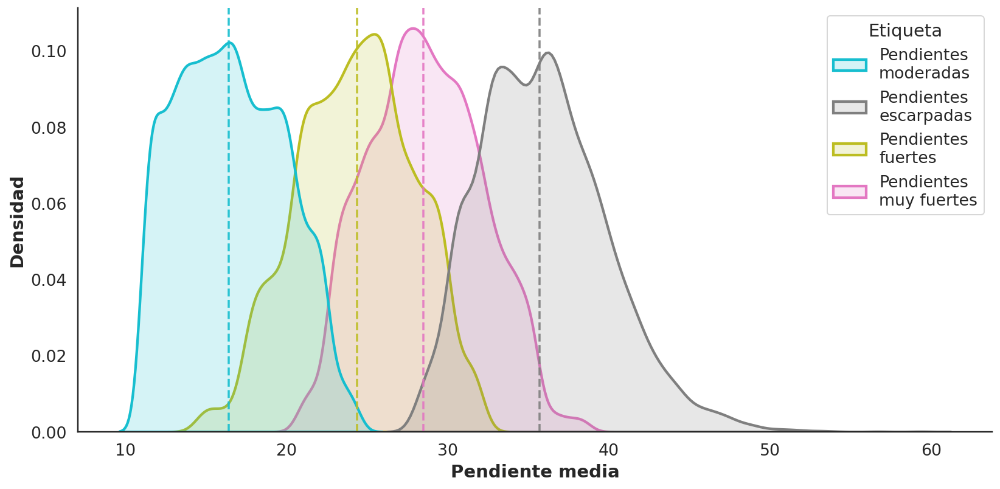

In [ ]:
# ── Densidad de pendientes por tipo de ladera ──────────────────────────
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# === 1) Cargar datos ===
dir_data = '../../DATA/shape_files/'
su = gpd.read_file(os.path.join(dir_data, 'slope_units_analisis.shp'))

# === 2) Saneo mínimo ===
su['cluster4']   = pd.to_numeric(su['cluster4'], errors='coerce').astype('Int64')
su['slope_mean'] = pd.to_numeric(su['slope_mean'], errors='coerce')

# Filtrar clases válidas y pendientes no negativas
valid = [0, 1, 2, 3]
su = su[su['cluster4'].isin(valid) & su['slope_mean'].notna() & (su['slope_mean'] >= 0)].copy()

# Mapear descripciones y asegurar orden de leyenda
desc_map = {
    0: 'Pendientes\nmoderadas',
    1: 'Pendientes\nescarpadas',
    2: 'Pendientes\nfuertes',
    3: 'Pendientes\nmuy fuertes'
}
su['Etiqueta'] = su['cluster4'].map(desc_map)

cat_order = [desc_map[i] for i in valid]  # 0→3
su['Etiqueta'] = pd.Categorical(su['Etiqueta'], categories=cat_order, ordered=True)

# Colores provistos (mapeados por etiqueta en el mismo orden 0→3)
palette = ['#17becf', '#7f7f7f', '#bcbd22', '#e377c2']
pal_dict = {lab: col for lab, col in zip(cat_order, palette)}

# === 3) Gráfico KDE (superpuesto) ===
sns.set_theme(style='white', font='DejaVu Sans', font_scale=1.25)

fig, ax = plt.subplots(figsize=(12, 6), dpi=140)

sns.kdeplot(
    data=su, x='slope_mean', hue='Etiqueta',
    fill=True, common_norm=False, alpha=0.18, linewidth=2.2,
    bw_adjust=1.0, clip=(0, None), palette=pal_dict, ax=ax
)

# Medianas por tipo (línea punteada del mismo color)
medianas = su.groupby('Etiqueta')['slope_mean'].median()
for lab, med in medianas.items():
    ax.axvline(med, color=pal_dict[lab], linestyle='--', linewidth=1.8, alpha=0.9)
# Nota visual para medianas
from matplotlib.lines import Line2D
handles, labels = ax.get_legend_handles_labels()
handles += [Line2D([0], [0], color='black', linestyle='--', linewidth=1.8)]
labels  += ['Mediana']
#ax.legend(handles, labels, title='Tipo de ladera', frameon=False, ncol=2)

# Etiquetas y estética
ax.set_xlabel('Pendiente media', weight='bold')
ax.set_ylabel('Densidad', weight='bold')
# ax.set_title('Distribución de pendientes por tipo de ladera', weight='bold', pad=12)

ax.spines[['right','top']].set_visible(False)
ax.grid(False)
plt.tight_layout()
# plt.savefig('kde_pendiente_por_tipo.png', dpi=300, bbox_inches='tight')
plt.show()


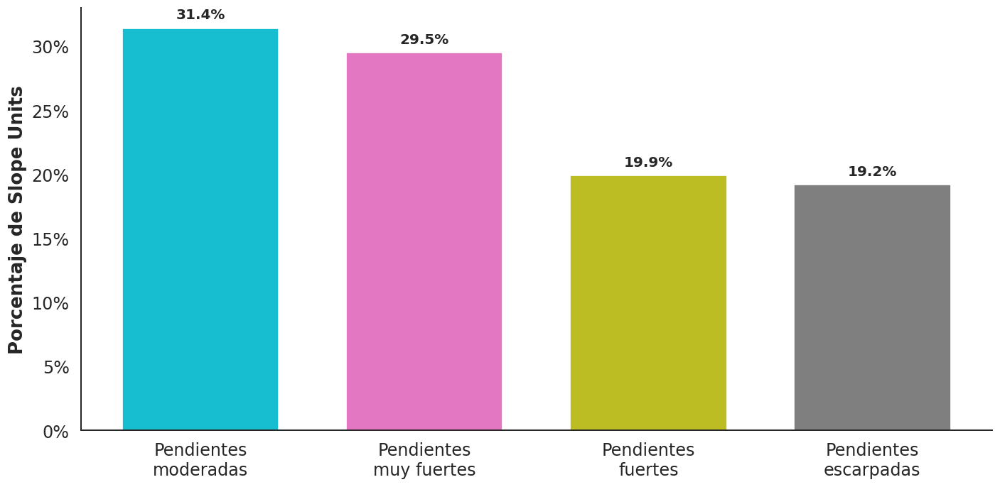

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import os

# === 1. Cargar datos ===
dir_data = '../../DATA/shape_files/'
su = gpd.read_file(os.path.join(dir_data, 'slope_units_analisis.shp'))

# === 2. Calcular porcentajes de cada tipo de ladera ===
# Contar unidades por tipo
counts = su['cluster4'].value_counts().sort_index()

# Calcular porcentajes
percentages = counts / counts.sum()

# Crear DataFrame para graficar
df = pd.DataFrame({
    'Tipo de Ladera': counts.index,
    'Porcentaje': percentages.values
})

# Mapear descripciones
desc_map = {
    0: 'Pendientes\nmoderadas',
    1: 'Pendientes\nescarpadas',
    2: 'Pendientes\nfuertes',
    3: 'Pendientes\nmuy fuertes'
}

df['Descripción'] = df['Tipo de Ladera'].map(desc_map)
# Ordenar por porcentaje de mayor a menor
df = df.sort_values(by='Porcentaje', ascending=False).reset_index(drop=True)

# === 3. Graficar ===
palette = ['#17becf', '#7f7f7f', '#bcbd22','#e377c2']

sns.set_theme(style='white', font='DejaVu Sans', font_scale=1.3)

fig, ax = plt.subplots(figsize=(12, 6), dpi=120)

bars = ax.bar(df['Descripción'], df['Porcentaje'], 
              color=[palette[i] for i in df['Tipo de Ladera']], width=0.7)

# Etiquetas encima de cada barra
for bar, pct in zip(bars, df['Porcentaje']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{pct*100:.1f}%',
        ha='center', va='bottom', fontsize=12, weight='bold'
    )

# Formato del eje Y
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

# Etiquetas y título
ax.set_ylabel('Porcentaje de Slope Units', weight='bold')
ax.set_xlabel('')
#ax.set_title('Distribución de tipos de laderas en la zona de estudio', weight='bold', pad=15)

# Quitar bordes innecesarios
ax.spines[['right', 'top']].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# Fondo blanco
ax.set_facecolor('white')
ax.grid(False)

plt.tight_layout()
#plt.savefig('porcentaje_tipos_laderas.png', dpi=300, bbox_inches='tight')
plt.show()


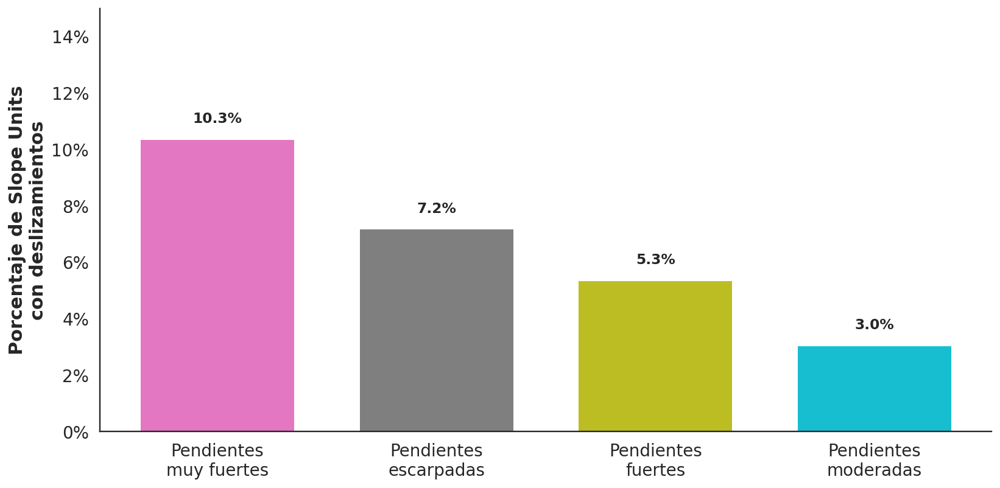

In [6]:
# ── % DE SLOPE UNITS CON DESLIZAMIENTOS POR TIPO DE LADERA ─────────────
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import os

# === 1) Cargar datos ===
dir_data = '../../DATA/shape_files/'
su = gpd.read_file(os.path.join(dir_data, 'slope_units_analisis.shp'))

# Asegurar tipos
su['cluster4'] = pd.to_numeric(su['cluster4'], errors='coerce').astype('Int64')
su['si_no']    = (pd.to_numeric(su['si_no'], errors='coerce').fillna(0) > 0).astype(int)

# === 2) Agregar por tipo de ladera ===
# 3) Agregación por tipo
valid = [0, 1, 2, 3]  # clases esperadas
df = (su.groupby('cluster4')
        .agg(Total=('cluster4', 'size'),
             Con_deslizamiento=('si_no', 'sum'))
        .reindex(valid).fillna(0)
        .rename_axis('cluster4')
        .reset_index())

df['Porcentaje'] = (df['Con_deslizamiento'] / df['Total'].replace(0, pd.NA)).fillna(0)


# Preparar etiquetas descriptivas
desc_map = {
    0: 'Pendientes\nmoderadas',
    1: 'Pendientes\nescarpadas',
    2: 'Pendientes\nfuertes',
    3: 'Pendientes\nmuy fuertes'
}

df['Descripción'] = df['cluster4'].map(desc_map)

# Orden (opcional): de mayor a menor porcentaje
df = df.sort_values('Porcentaje', ascending=False).reset_index(drop=True)

# 5) Gráfico
palette = ['#17becf', '#7f7f7f', '#bcbd22','#e377c2']
sns.set_theme(style='white', font='DejaVu Sans', font_scale=1.3)

fig, ax = plt.subplots(figsize=(12, 6), dpi=140)

bars = ax.bar(df['Descripción'], df['Porcentaje'],
              color=[palette[int(c)] for c in df['cluster4']],
              width=0.7, edgecolor='none')

for b, p in zip(bars, df['Porcentaje']):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
            f'{p*100:.1f}%', ha='center', va='bottom', fontsize=12, weight='bold')

ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_ylim(0, float(max(0.15, df['Porcentaje'].max()*1.15)))

ax.set_ylabel('Porcentaje de Slope Units\ncon deslizamientos', weight='bold')
ax.set_xlabel('')

ax.spines[['right','top']].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.grid(False)

plt.tight_layout()
# plt.savefig('porcentaje_su_con_deslizamiento_por_tipo.png', dpi=300, bbox_inches='tight')
plt.show()


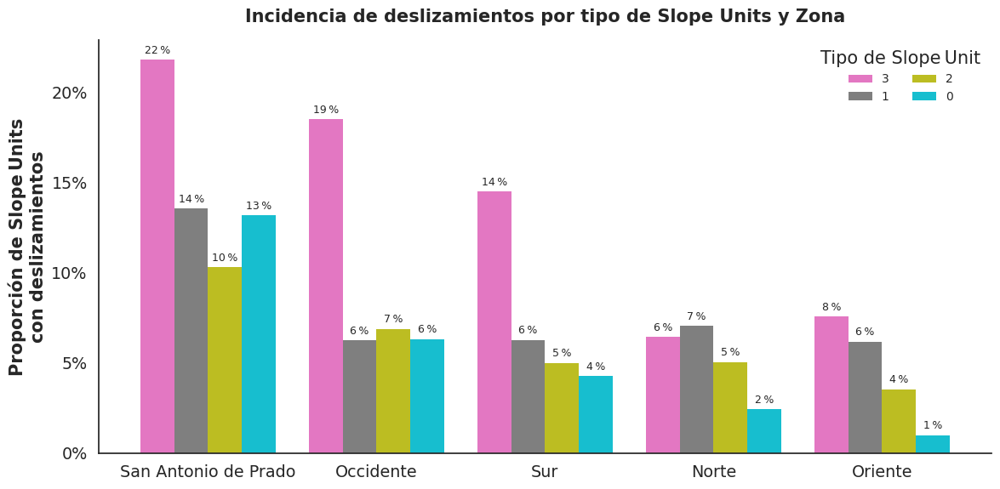

In [27]:
#3. Calcular métricas normalizadas por zona y tipo de ladera
#abrir su
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter, MultipleLocator
import os



dir_data   = '../../DATA/shape_files/'
su = gpd.read_file(os.path.join(dir_data, 'slope_units_analisis.shp'))
agg = (
    su
    .groupby(['zona','cluster4'])
    .agg(
        total_units=('su_idx','count'),
        slides_units=('si_no','sum'),
        total_slides=('n_mm','sum')
    )
    .assign(
        prop_unidades_con_slides=lambda df: df['slides_units'] / df['total_units'], #Permite saber cuán “frecuente” es el fenómeno independientemente de cuántas unidades existan. Ideal para comparar zonas con distinto número de polígonos.
        mean_slides_por_unidad=lambda df: df['total_slides'] / df['total_units'] #Mide la “intensidad” del problema: no solo cuántas unidades tienen deslizamientos, sino cuántos eventos acumula cada una, en promedio.
    )
    .reset_index()
)


zona_map = {1:'Oriente', 
            2:'Norte', 
            3:'Sur', 
            4:'San Antonio de Prado', 
            5:'Occidente'}

agg['zona_nombre'] = agg['zona'].map(zona_map)

# ─────── ORDEN DINÁMICO ────────────────────────────────────────────────
# Zonas por mayor proporción promedio
zona_order = (
    agg.groupby('zona_nombre')['prop_unidades_con_slides']
       .mean()
       .sort_values(ascending=False)
       .index
)

# Tipos de ladera (columnas) por mayor media general
cluster_order = (
    agg.groupby('cluster4')['prop_unidades_con_slides']
       .mean()
       .sort_values(ascending=False)
       .index
)

dfp2 = (
    agg.pivot(index='zona_nombre', columns='cluster4', values='prop_unidades_con_slides')
       .loc[zona_order, cluster_order]
)

# 4. Graficar barras agrupadas

# Paleta tab10 (últimos 4 colores)
palette = ['#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

sns.set_theme(style='white', font='DejaVu Sans', font_scale=1.25)

# 12×6 in → 1200×600 px con dpi = 100: buena proporción 16:9 para diapositiva
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

dfp2.plot(kind='bar', ax=ax, color=palette, width=0.8, edgecolor='none')

# Etiquetas sobre barras
for cont in ax.containers:
    ax.bar_label(
        cont,
        labels=[f'{v*100:.0f} %' if pd.notna(v) else '' for v in cont.datavalues],
        padding=3, fontsize=9
    )

# Eje Y
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_locator(MultipleLocator(0.05))
ax.tick_params(axis='y', which='major', length=6, width=1, direction='out')

# Etiquetas y estética
ax.set_ylabel('Proporción de Slope Units\ncon deslizamientos', weight='bold')
ax.set_xlabel('')
ax.set_title('Incidencia de deslizamientos por tipo de Slope Units y Zona',
             weight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')

# Mantener solo ejes izquierdo y abajo
ax.spines[['left', 'bottom']].set_visible(True)
ax.spines[['right', 'top']].set_visible(False)

ax.grid(False)
ax.legend(title='Tipo de Slope Unit', frameon=False, ncol=2, fontsize=10)

plt.tight_layout()

# Guarda la imagen lista para la diapositiva
plt.savefig('incidencia_slope_units.png', dpi=100, bbox_inches='tight', transparent=False)
plt.show()

| Posición | Color (HEX) |
| -------- | ----------- |
| 1        | `#1f77b4`   |
| 2        | `#ff7f0e`   |
| 3        | `#2ca02c`   |
| 4        | `#d62728`   |
| 5        | `#9467bd`   |
| 6        | `#8c564b`   |
| 7        | `#e377c2`   |
| 8        | `#7f7f7f`   |
| 9        | `#bcbd22`   |
| 10       | `#17becf`   |

/tmp/ipykernel_2557876/3501660036.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2557876/3501660036.py:82: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')


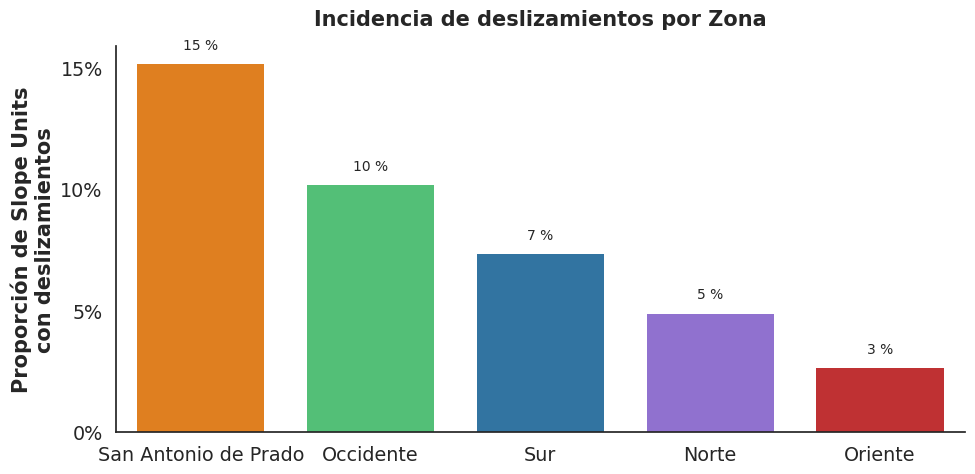

In [2]:
# ---------------- 1. Cargar librerías y datos ------------------------
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter, MultipleLocator
import os

dir_data = '../../DATA/shape_files/'
su = gpd.read_file(os.path.join(dir_data, 'slope_units_analisis.shp'))

# ---------------- 2. Agregación SOLO por zona ------------------------
agg_z = (
    su
    .groupby('zona')
    .agg(
        total_units  = ('su_idx', 'count'),
        slides_units = ('si_no',  'sum'),
        total_slides = ('n_mm',   'sum')
    )
    .assign(
        prop_unidades_con_slides = lambda df:
            df['slides_units'] / df['total_units'],
        mean_slides_por_unidad   = lambda df:
            df['total_slides'] / df['total_units']
    )
    .reset_index()
)

# ---------------- 3. Nombrar y ordenar zonas -------------------------
zona_map = {1:'Oriente', 2:'Norte', 3:'Sur',
            4:'San Antonio de Prado', 5:'Occidente'}
agg_z['zona_nombre'] = agg_z['zona'].map(zona_map)

agg_z = agg_z.sort_values('prop_unidades_con_slides', ascending=False)

# ---------------- 4. Colores personalizados por zona -----------------
colores = {
    1: '#d7191c',# Oriente
    2: '#8b61df',  # Norte
    3: '#1f78b4',  # Sur
    4: '#ff7f00',  # San Antonio de Prado
    5: '#41d171' # Occidente
}

# Se construye la paleta en el mismo orden en que aparecerán las barras
palette = [colores[z] for z in agg_z['zona']]

# ---------------- 5. Gráfica de barras -------------------------------
sns.set_theme(style='white', font='DejaVu Sans', font_scale=1.25)

fig, ax = plt.subplots(figsize=(10, 5), dpi=100)

sns.barplot(
    data     = agg_z,
    x        = 'zona_nombre',
    y        = 'prop_unidades_con_slides',
    ax       = ax,
    palette  = palette,      # ← paleta definida arriba
    width    = 0.75,
    edgecolor='none'
)

# Etiquetas de porcentaje sobre cada barra
for p in ax.patches:
    value = p.get_height()
    ax.text(
        x  = p.get_x() + p.get_width()/2,
        y  = value + 0.005,
        s  = f'{value*100:.0f} %',
        ha = 'center', va='bottom', fontsize=10
    )

# Formato eje Y
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_locator(MultipleLocator(0.05))

# Etiquetas y estilo
ax.set_ylabel('Proporción de Slope Units\ncon deslizamientos', weight='bold')
ax.set_xlabel('')
ax.set_title('Incidencia de deslizamientos por Zona', weight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
#plt.savefig('incidencia_slope_units_zonas.png', dpi=100, bbox_inches='tight')
plt.show()


/tmp/ipykernel_2557876/1346172632.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2557876/1346172632.py:84: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')


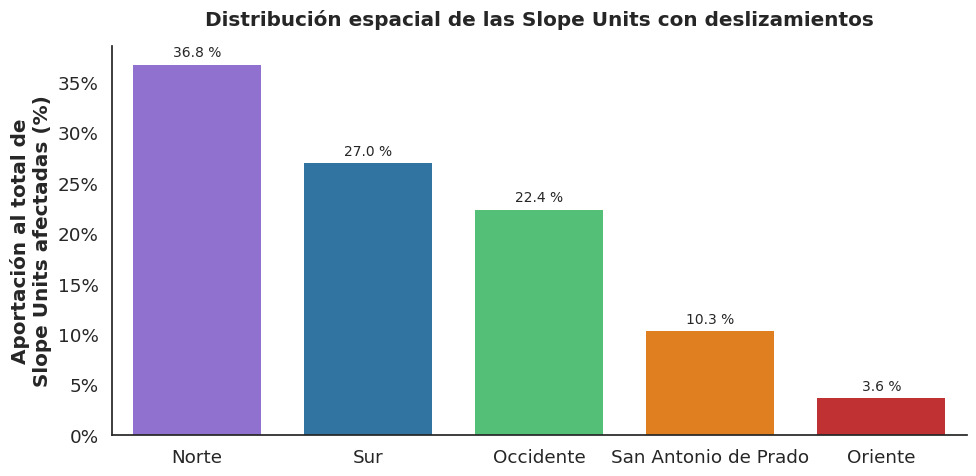

In [5]:
# ---------------- 1. Cargar librerías y datos ------------------------
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter, MultipleLocator
import os

dir_data = '../../DATA/shape_files/'
su = gpd.read_file(os.path.join(dir_data, 'slope_units_analisis.shp'))

# ---------------- 2. Agregación SOLO por zona ------------------------
agg_z = (
    su
    .groupby('zona')
    .agg(
        total_units  = ('su_idx', 'count'),
        slides_units = ('si_no',  'sum')
    )
    .reset_index()
)

# ---------------- 3. Porcentaje que aporta cada zona -----------------
total_afectadas = agg_z['slides_units'].sum()

agg_z['aportacion_pct'] = (
    agg_z['slides_units'] / total_afectadas * 100
)

# Orden descendente para que primero aparezcan las zonas
# que concentran más unidades afectadas.
agg_z = agg_z.sort_values('aportacion_pct', ascending=False)

# ---------------- 4. Diccionario de nombres y colores ----------------
zona_map = {1:'Oriente', 2:'Norte', 3:'Sur',
            4:'San Antonio de Prado', 5:'Occidente'}
agg_z['zona_nombre'] = agg_z['zona'].map(zona_map)

colores = {
    1: '#d7191c',# Oriente
    2: '#8b61df',  # Norte
    3: '#1f78b4',  # Sur
    4: '#ff7f00',  # San Antonio de Prado
    5: '#41d171' # Occidente
}

palette = [colores[z] for z in agg_z['zona']]

# ---------------- 5. Gráfica de barras -------------------------------
sns.set_theme(style='white', font='DejaVu Sans', font_scale=1.2)

fig, ax = plt.subplots(figsize=(10, 5), dpi=100)

sns.barplot(
    data     = agg_z,
    x        = 'zona_nombre',
    y        = 'aportacion_pct',
    ax       = ax,
    palette  = palette,
    width    = 0.75,
    edgecolor='none'
)

# Etiquetas numéricas sobre cada barra
for p in ax.patches:
    value = p.get_height()
    ax.text(
        x  = p.get_x() + p.get_width() / 2,
        y  = value + 0.5,                  # pequeño desplazamiento
        s  = f'{value:.1f} %',
        ha = 'center', va='bottom', fontsize=10
    )

# Formato eje Y
ax.yaxis.set_major_formatter(PercentFormatter(100, decimals=0))
ax.yaxis.set_major_locator(MultipleLocator(5))

# Etiquetas y estilo
ax.set_ylabel('Aportación al total de\nSlope Units afectadas (%)', weight='bold')
ax.set_xlabel('')
ax.set_title('Distribución espacial de las Slope Units con deslizamientos',
             weight='bold', pad=15)

ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
# plt.savefig('aportacion_slope_units_afectadas_por_zona.png',
#             dpi=100, bbox_inches='tight')
plt.show()


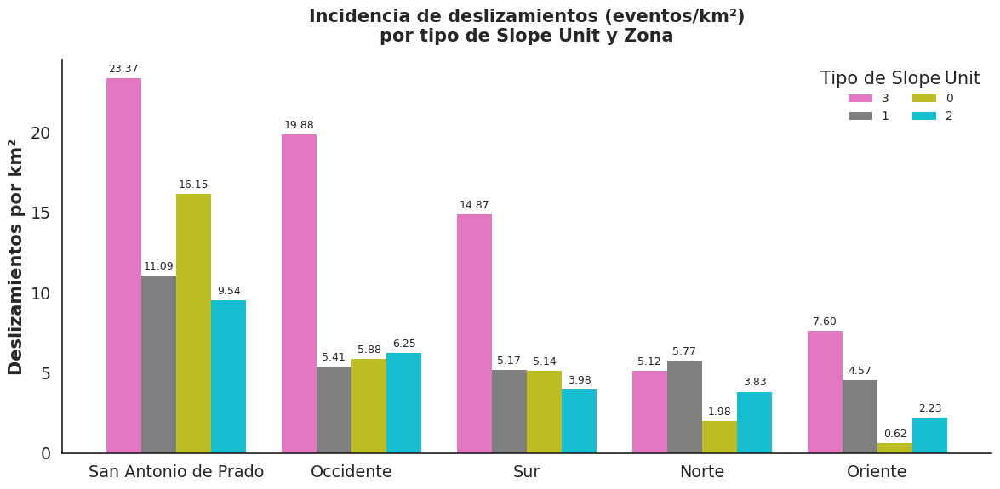

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter, MultipleLocator
import os

# ─── Cargar y preparar datos ─────────────────────────────────────────────
dir_data = '../../DATA/shape_files/'
su = gpd.read_file(os.path.join(dir_data, 'slope_units_analisis.shp'))

# Asegurar proyección métrica para áreas
if su.crs.is_geographic:
    su = su.to_crs(32618)          # UTM 18 N (m)

su['area_km2'] = su.geometry.area / 1e6      # área en km²

agg = (su
       .groupby(['zona', 'cluster4'])
       .agg(total_slides=('n_mm', 'sum'),
            area_km2=('area_km2', 'sum'))
       .assign(slides_x_km2=lambda d: d.total_slides / d.area_km2)
       .reset_index())

zona_map = {1: 'Oriente', 2: 'Norte', 3: 'Sur',
            4: 'San Antonio de Prado', 5: 'Occidente'}
agg['zona_nombre'] = agg['zona'].map(zona_map)

zona_order = (agg.groupby('zona_nombre')['slides_x_km2']
                 .mean()
                 .sort_values(ascending=False)
                 .index)

cluster_order = (agg.groupby('cluster4')['slides_x_km2']
                   .mean()
                   .sort_values(ascending=False)
                   .index)

dfp_area = (agg.pivot(index='zona_nombre',
                      columns='cluster4',
                      values='slides_x_km2')
               .loc[zona_order, cluster_order])

# ─── Gráfico ─────────────────────────────────────────────────────────────
palette = ['#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
sns.set_theme(style='white', font='DejaVu Sans', font_scale=1.25)

fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
dfp_area.plot(kind='bar', ax=ax, color=palette, width=0.8, edgecolor='none')

for cont in ax.containers:
    ax.bar_label(cont,
                 labels=[f'{v:.2f}' if pd.notna(v) else '' for v in cont.datavalues],
                 padding=3, fontsize=9)

ax.set_ylabel('Deslizamientos por km²', weight='bold')
ax.set_xlabel('')
ax.set_title('Incidencia de deslizamientos (eventos/km²)\npor tipo de Slope Unit y Zona',
             weight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')

ax.yaxis.set_major_locator(MultipleLocator(5))
ax.tick_params(axis='y', which='major', length=6, width=1, direction='out')
ax.tick_params(axis='y', which='minor', length=0, width=0)
ax.spines[['left', 'bottom']].set_visible(True)
ax.spines[['right', 'top']].set_visible(False)
ax.grid(False)
ax.legend(title='Tipo de Slope Unit', frameon=False, ncol=2, fontsize=10)

plt.tight_layout()
plt.savefig('deslizamientos_km2_slope_units.png',
            dpi=100, bbox_inches='tight', transparent=False)
plt.show()


In [54]:
import geopandas as gpd, pandas as pd, numpy as np

su = gpd.read_file('../../DATA/shape_files/slope_units_analisis.shp')

# pasar a métrico si fuera necesario
if su.crs.is_geographic:
    su = su.to_crs(32618)

# variables continuas en un solo DataFrame
num_cols = ['slope_mean', 'tpi_mean', 'twi_mean', 'flowacum_m']
df_num   = su[num_cols + ['cluster4']]

# variables categóricas
cat_cols = ['ugs_majo', 'cobertura', 'curvatura']
df_cat   = su[cat_cols + ['cluster4']]

# Aspecto como ángulo radianes + sin/cos para análisis lineal
su['aspect_rad'] = np.deg2rad(su['aspect_maj'])
su['aspect_sin'] = np.sin(su['aspect_rad'])
su['aspect_cos'] = np.cos(su['aspect_rad'])


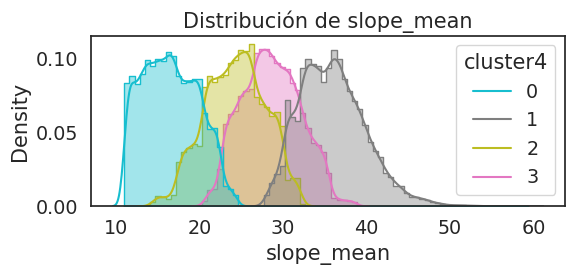

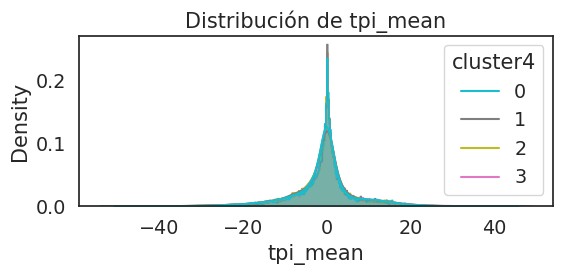

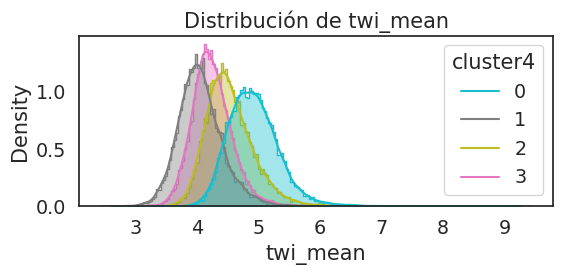

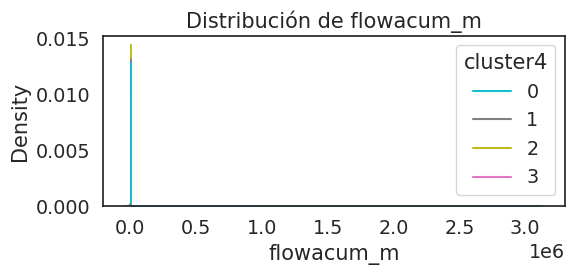

In [61]:
import seaborn as sns, matplotlib.pyplot as plt
palette = ['#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# Colores oficiales
colors = {                       #  id : HEX
    0: '#17becf',   # azul‑cyan
    1: '#7f7f7f',   # gris
    2: '#bcbd22',   # verde mostaza
    3: '#e377c2'    # magenta
}

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(data=df_num, x=col, hue='cluster4',
                 element='step', stat='density', common_norm=False,
                 palette=colors, alpha=0.4)
    sns.kdeplot(data=df_num, x=col, hue='cluster4',
                palette=colors, common_norm=False)
    plt.title(f'Distribución de {col}')
    plt.tight_layout()
    plt.show()


### POR ZONA

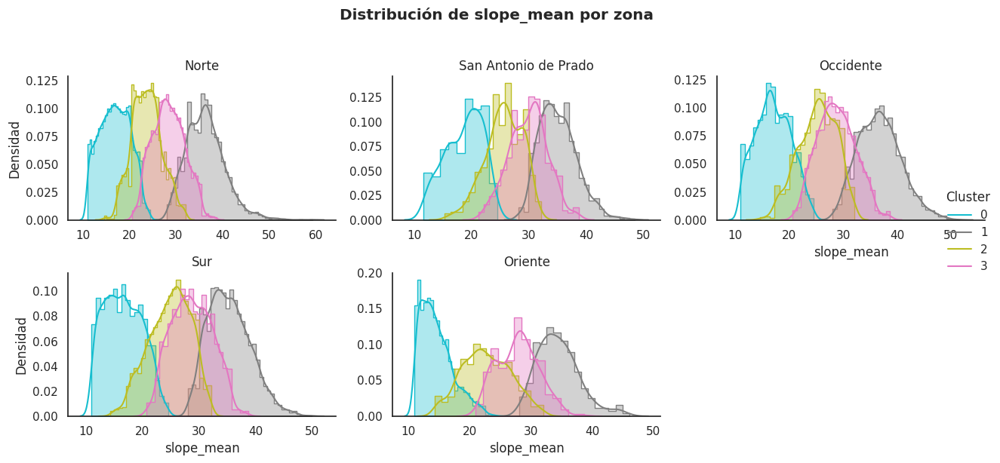

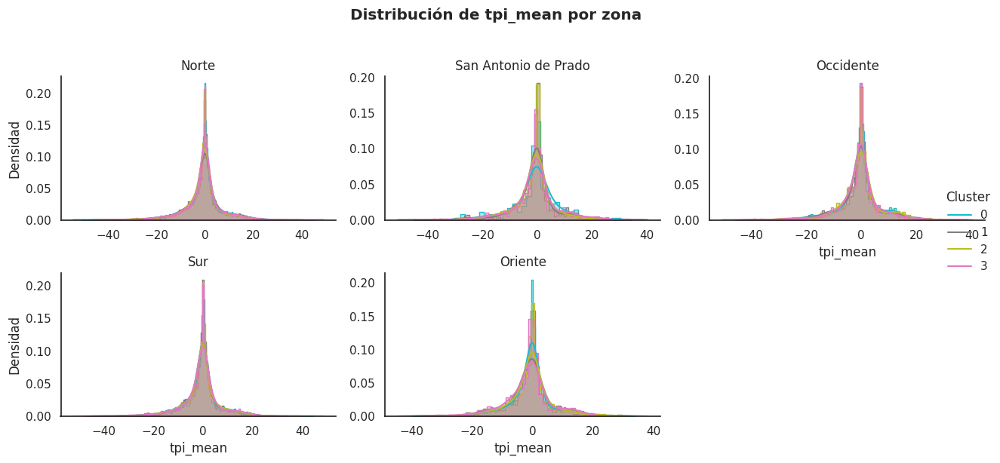

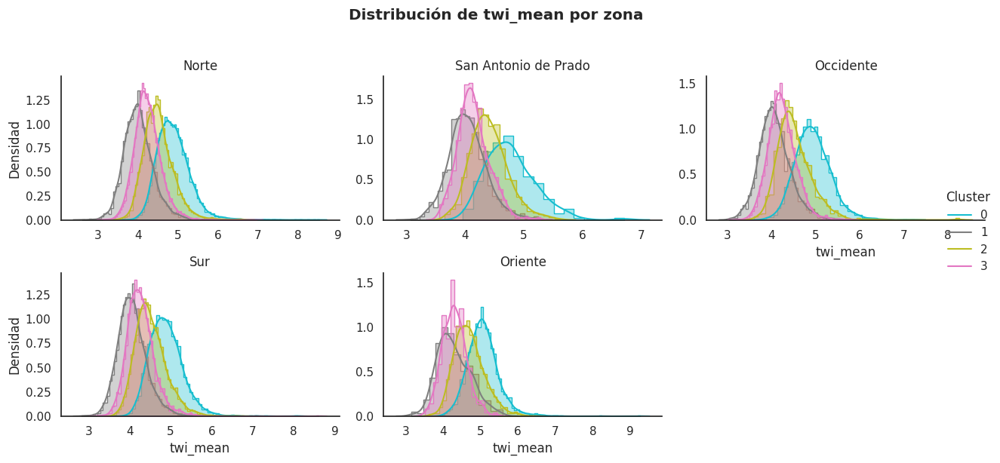

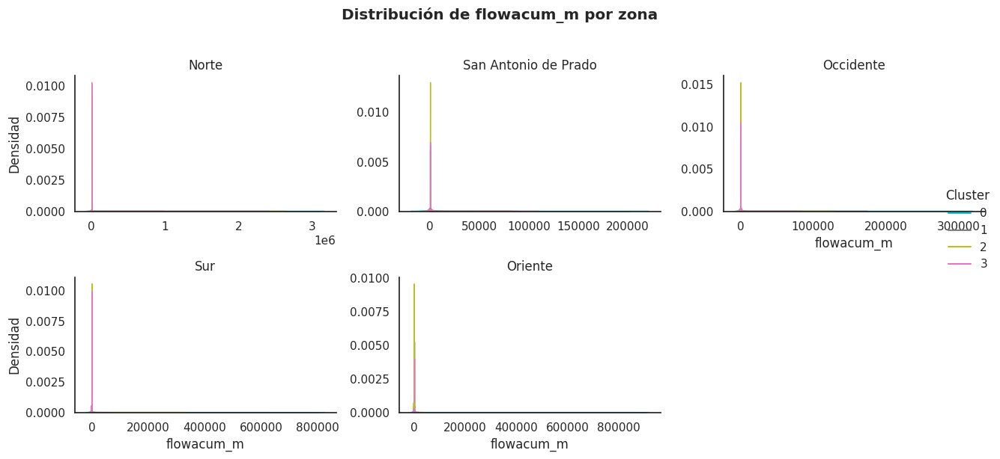

In [1]:
import geopandas as gpd, pandas as pd, numpy as np
import seaborn as sns, matplotlib.pyplot as plt

# ─── Cargar shapefile ───────────────────────────────────────────────
su = gpd.read_file('../../DATA/shape_files/slope_units_analisis.shp')
if su.crs.is_geographic:
    su = su.to_crs(32618)

# ─── Variables numéricas y zona ────────────────────────────────────
num_cols = ['slope_mean', 'tpi_mean', 'twi_mean', 'flowacum_m']
df      = su[num_cols + ['cluster4', 'zona']].copy()

# nombre legible de zona (opcional)
zona_map = {1:'Oriente', 2:'Norte', 3:'Sur',
            4:'San Antonio de Prado', 5:'Occidente'}
df['zona_nom'] = df['zona'].map(zona_map)

# ─── Paleta fija por cluster ───────────────────────────────────────
colors = {0:'#17becf', 1:'#7f7f7f', 2:'#bcbd22', 3:'#e377c2'}

# ─── Histograma + KDE por zona ─────────────────────────────────────
sns.set_theme(style='white', font='DejaVu Sans')

for col in num_cols:
    g = sns.FacetGrid(data=df,
                      col='zona_nom',
                      col_wrap=3,            # 3 zonas por fila
                      height=3, aspect=1.4,
                      hue='cluster4',
                      palette=colors,
                      sharex=False, sharey=False)
    
    g.map(sns.histplot, col,
          element='step', stat='density',
          common_norm=False, alpha=0.35)
    g.map(sns.kdeplot,  col,
          common_norm=False)
    
    g.add_legend(title='Cluster')
    g.set_axis_labels(col, 'Densidad')
    g.set_titles('{col_name}')
    g.fig.suptitle(f'Distribución de {col} por zona', y=1.02, weight='bold')
    plt.tight_layout()
    plt.show()


In [2]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.violinplot(data=df_num, x='cluster4', y=col,
                   inner='box', palette=colors)
    plt.title(col)
    plt.tight_layout()
    plt.show()


NameError: name 'df_num' is not defined

<Figure size 500x300 with 0 Axes>

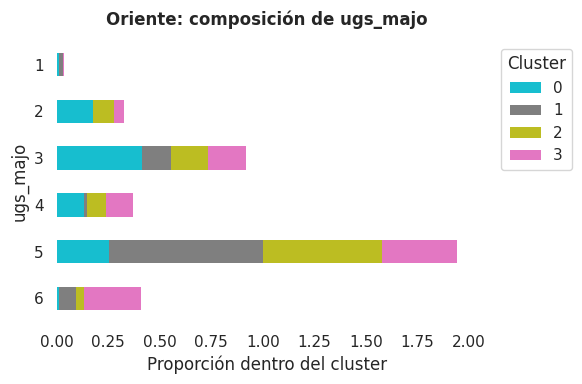

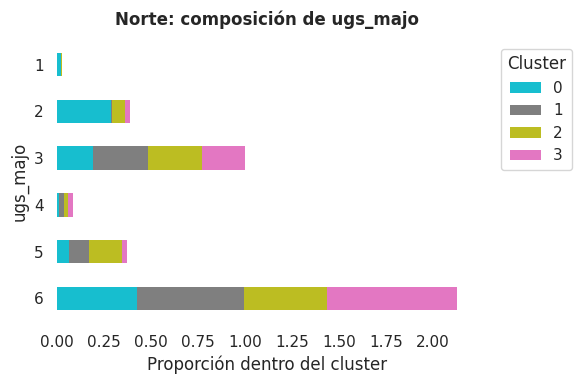

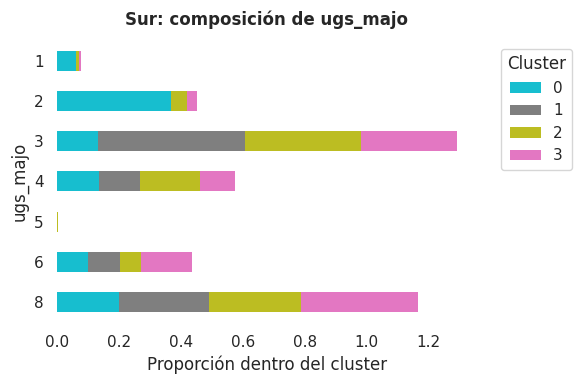

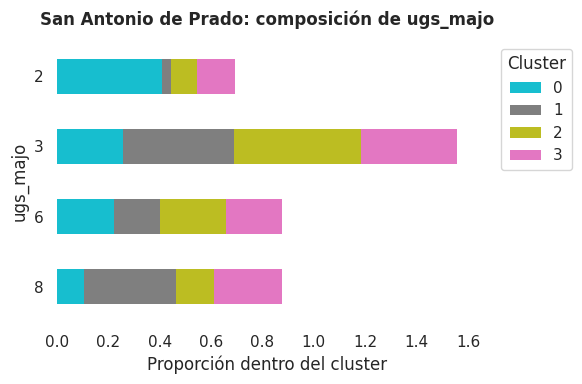

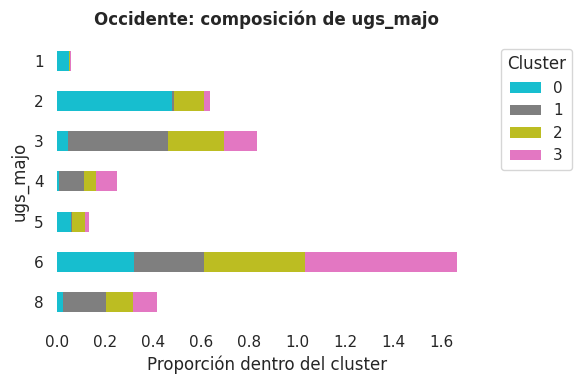

KeyError: "None of [Index([0, 1, 2, 3], dtype='int64', name='cluster4')] are in the [columns]"

In [2]:
import geopandas as gpd, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

# ─── Cargar datos ──────────────────────────────────────────────────────
su = gpd.read_file('../../DATA/shape_files/slope_units_analisis.shp')
if su.crs.is_geographic:
    su = su.to_crs(32618)

# ─── Variables categóricas + zona ─────────────────────────────────────
cat_cols = ['ugs_majo', 'curvatura'] #'cobertura', 
df_cat   = su[cat_cols + ['cluster4', 'zona']]

# ─── Diccionario de colores fijo por cluster ──────────────────────────
colors = {0:'#17becf', 1:'#7f7f7f', 2:'#bcbd22', 3:'#e377c2'}
cluster_order = [0,1,2,3]                       # orden constante

# ─── Diccionario de nombres de zona (opcional) ────────────────────────
zona_map = {1:'Oriente', 2:'Norte', 3:'Sur',
            4:'San Antonio de Prado', 5:'Occidente'}

# ─── Barras apiladas por zona ─────────────────────────────────────────
sns.set_theme(style='white', font='DejaVu Sans')

for col in cat_cols:
    for zona_id in sorted(df_cat['zona'].unique()):
        zname = zona_map.get(zona_id, f'Zona {zona_id}')
        sub   = df_cat[df_cat['zona']==zona_id]

        # Tabla de frecuencias → proporción dentro de cada cluster
        ctab = (pd.crosstab(sub[col], sub['cluster4'], normalize='columns')
                  .reindex(sorted(sub[col].unique(), reverse=True)))   # opcional

        # Asegurar que las columnas salgan 0-1-2-3 en orden fijo
        ctab = ctab[cluster_order]

        # Colores en el mismo orden
        bar_colors = [colors[c] for c in cluster_order]

        ax = ctab.plot(kind='barh', stacked=True, color=bar_colors,
                       figsize=(6,4), edgecolor='none')

        ax.set_title(f'{zname}: composición de {col}', weight='bold', pad=12)
        ax.set_xlabel('Proporción dentro del cluster')
        ax.set_ylabel(col)
        ax.legend(title='Cluster', bbox_to_anchor=(1.04,1), loc='upper left')
        sns.despine(ax=ax, left=True, bottom=True)
        plt.tight_layout()
        plt.show()


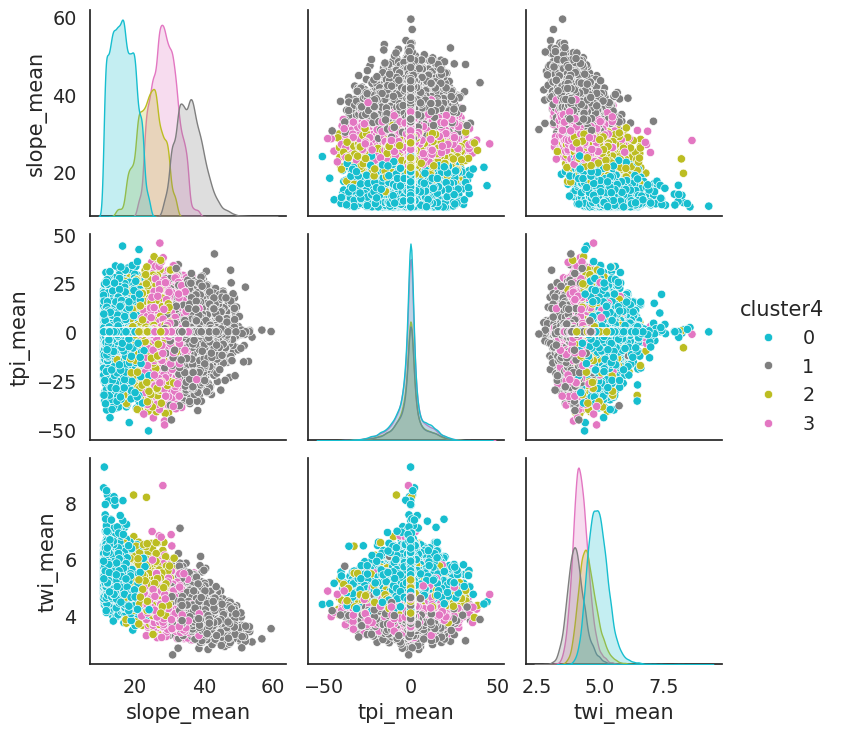

In [65]:
sns.pairplot(su[['slope_mean','tpi_mean','twi_mean','cluster4']],
             hue='cluster4', palette=colors, diag_kind='kde')
plt.show()
